# Configuración inicial

In [54]:
!pip install -q sentence-transformers xgboost

## 01 - Librerias y configuración

In [55]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

### RUTAS

NEWS_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/news_raw_colombia_con_fuente.csv"
PRICES_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/precios_colombia.csv"

EMBEDDINGS_CACHE_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/news_embeddings_mpnet.npy"
NEWS_WITH_EMB_CACHE_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/news_with_embedding_index.csv"

### Conf adicionales
TRAIN_END = "2023-12-31"
VAL_START = "2024-01-01"
VAL_END = "2024-12-31"
TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

ROLLING_WINDOW_NEWS = 5
LOOKBACK_DAYS = 20

BATCH_SIZE_EMBEDDINGS = 32
BATCH_SIZE_DL = 64

EPOCHS_DL = 25
PATIENCE_DL = 5
LEARNING_RATE_DL = 1e-3

# Rolling horizon 2025
ROLLING_RETRAIN_EVERY_N_DAYS = 1
MIN_TRAIN_ROWS_ROLLING = 300

DEVICE: cpu


## 02 - Carga de los datos

In [56]:
news_df = pd.read_csv(NEWS_PATH)
prices_df = pd.read_csv(PRICES_PATH)

news_df["fecha"] = pd.to_datetime(news_df["fecha"])
prices_df["fecha"] = pd.to_datetime(prices_df["fecha"])

news_df["stock"] = news_df["stock"].astype(str)
prices_df["stock"] = prices_df["stock"].astype(str)

news_df = news_df.sort_values(["stock", "fecha"]).reset_index(drop=True)
prices_df = prices_df.sort_values(["stock", "fecha"]).reset_index(drop=True)

print("Noticias:", news_df.shape)
print("Precios:", prices_df.shape)

display(news_df.head())
display(prices_df.head())

print("\nColumnas noticias:")
print(news_df.columns.tolist())

print("\nColumnas precios:")
print(prices_df.columns.tolist())

print("\nRango noticias:", news_df["fecha"].min(), "->", news_df["fecha"].max())
print("Rango precios:", prices_df["fecha"].min(), "->", prices_df["fecha"].max())

print("\nStocks noticias:", sorted(news_df["stock"].unique()))
print("Stocks precios:", sorted(prices_df["stock"].unique()))

Noticias: (3000, 19)
Precios: (5008, 12)


,fecha,stock,company_name,title,summary,text,source,domain,url,query_used,source_type,is_priority_source,relevance_score,is_relevant,sentiment_label,sentiment_value,sentiment_score,extraction_date,notes
0,2021-01-13,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,"""Grupo Argos"" AND ""recompra de acciones""",medio económico,True,0.72,True,POS,1,0.91,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
1,2021-01-14,ARG,Grupo Argos,Grupo Argos convoca a reunión extraordinaria d...,El orden del día contempla modificaciones esta...,El orden del día contempla modificaciones esta...,El Espectador,elespectador.com,https://www.elespectador.com/contenido/arg-not...,Grupo Argos AND asambleas,prensa,True,0.71,True,NEU,0,0.96,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
2,2021-01-14,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,La República,larepublica.co,https://www.larepublica.co/contenido/arg-notic...,"""Grupo Argos"" AND ""recompra de acciones""",medio económico,True,0.88,True,POS,1,0.92,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
3,2021-01-24,ARG,Grupo Argos,Odinsa y Celsia reportan hitos de infraestruct...,Las filiales del grupo superaron las metas ope...,Las filiales del grupo superaron las metas ope...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,Celsia OR Odinsa,medio económico,True,0.74,True,POS,1,0.77,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
4,2021-02-10,ARG,Grupo Argos,Cementos Argos consolida fusión estratégica en...,La operación genera sinergias operativas y exp...,La operación genera sinergias operativas y exp...,Reuters Latam,reuters.com,https://www.reuters.com/contenido/arg-noticia-...,Cementos Argos AND inversiones,prensa,False,0.96,True,POS,1,0.86,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...


,fecha,stock,open,high,low,close,volume,return_1d,volatility_5,ma_5,ma_10,target
0,2021-01-14,ARG,14000.0,14000.0,13600.0,11268.315430,156940,0.019665,0.018500,11147.582227,11114.963379,0
1,2021-01-15,ARG,14000.0,14100.0,13800.0,11268.315430,108784,0.000000,0.012302,11179.777539,11130.842969,0
2,2021-01-18,ARG,13900.0,13900.0,13670.0,11187.826172,117277,-0.007143,0.013117,11195.875000,11131.480469,1
3,2021-01-19,ARG,13960.0,14000.0,13840.0,11236.117188,46560,0.004316,0.012656,11202.313867,11144.140234,0
4,2021-01-20,ARG,13900.0,13960.0,13840.0,11187.826172,129726,-0.004298,0.010528,11229.680078,11135.186914,0



Columnas noticias:
['fecha', 'stock', 'company_name', 'title', 'summary', 'text', 'source', 'domain', 'url', 'query_used', 'source_type', 'is_priority_source', 'relevance_score', 'is_relevant', 'sentiment_label', 'sentiment_value', 'sentiment_score', 'extraction_date', 'notes']

Columnas precios:
['fecha', 'stock', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'volatility_5', 'ma_5', 'ma_10', 'target']

Rango noticias: 2021-01-01 00:00:00 -> 2025-12-31 00:00:00
Rango precios: 2021-01-14 00:00:00 -> 2025-12-31 00:00:00

Stocks noticias: ['ARG', 'CIBEST', 'EC', 'NCH']
Stocks precios: ['ARG', 'CIBEST', 'EC', 'NCH']


## 03 - Pre validación

In [57]:
required_news_cols = ["fecha", "stock", "title", "summary", "text"]
required_price_cols = [
    "fecha", "stock", "open", "high", "low", "close",
    "volume", "return_1d", "volatility_5", "ma_5", "ma_10", "target"
]

missing_news = [c for c in required_news_cols if c not in news_df.columns]
missing_prices = [c for c in required_price_cols if c not in prices_df.columns]

if missing_news:
    raise ValueError(f"Faltan columnas en noticias: {missing_news}")

if missing_prices:
    raise ValueError(f"Faltan columnas en precios: {missing_prices}")

print("Valores target:")
print(prices_df["target"].value_counts(dropna=False))

print("\nNoticias por stock:")
print(news_df["stock"].value_counts())

print("\nPrecios por stock:")
print(prices_df["stock"].value_counts())

print("\nDuplicados precios fecha-stock:", prices_df.duplicated(["fecha", "stock"]).sum())
print("Duplicados noticias exactos fecha-stock-url:", news_df.duplicated(["fecha", "stock", "url"]).sum() if "url" in news_df.columns else "Sin URL")

Valores target:
target
0    2804
1    2204
Name: count, dtype: int64

Noticias por stock:
stock
EC        1236
CIBEST     720
NCH        620
ARG        424
Name: count, dtype: int64

Precios por stock:
stock
ARG       1276
NCH       1275
EC        1246
CIBEST    1211
Name: count, dtype: int64

Duplicados precios fecha-stock: 0
Duplicados noticias exactos fecha-stock-url: 0


# Preparación de datos

## 04 - Construcción texto para embeddings

In [58]:
for col in ["title", "summary", "text"]:
    news_df[col] = news_df[col].fillna("").astype(str)

# Escenario principal:
# Usa título + resumen + texto completo.
news_df["texto_modelo"] = (
    news_df["title"].str.strip()
    + ". "
    + news_df["summary"].str.strip()
    + ". "
    + news_df["text"].str.strip()
)

# ESCENARIO ALTERNATIVO:
news_df["texto_modelo"] = (
    news_df["title"].str.strip()
    + ". "
    + news_df["summary"].str.strip()
)

# news_df["texto_modelo"] = (
#     news_df["texto_modelo"]
#     .str.replace(r"\s+", " ", regex=True)
#     .str.strip()
# )

news_df["texto_modelo"] = news_df["texto_modelo"].replace("", "sin información textual disponible")

print(news_df[["fecha", "stock", "texto_modelo"]].head())
print("\nLongitud promedio del texto:", news_df["texto_modelo"].str.len().mean())

       fecha stock                                       texto_modelo
0 2021-01-13   ARG  Grupo Argos anuncia ambicioso plan de recompra...
1 2021-01-14   ARG  Grupo Argos convoca a reunión extraordinaria d...
2 2021-01-14   ARG  Grupo Argos anuncia ambicioso plan de recompra...
3 2021-01-24   ARG  Odinsa y Celsia reportan hitos de infraestruct...
4 2021-02-10   ARG  Cementos Argos consolida fusión estratégica en...

Longitud promedio del texto: 164.37666666666667


## 05 - Creación embeddings

In [59]:
def create_or_load_embeddings(news_df, model_name, cache_path, batch_size=32):
    """
    Crea embeddings por noticia o los carga desde cache si ya existen.
    """
    if os.path.exists(cache_path):
        print(f"Cargando embeddings desde cache: {cache_path}")
        embeddings = np.load(cache_path)
        return embeddings

    print(f"Cargando modelo de embeddings: {model_name}")
    model = SentenceTransformer(model_name, device=DEVICE)

    texts = news_df["texto_modelo"].tolist()

    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )

    np.save(cache_path, embeddings)
    print(f"Embeddings guardados en: {cache_path}")

    return embeddings


news_embeddings = create_or_load_embeddings(
    news_df=news_df,
    model_name=EMBEDDING_MODEL_NAME,
    cache_path=EMBEDDINGS_CACHE_PATH,
    batch_size=BATCH_SIZE_EMBEDDINGS
)

print("Shape embeddings:", news_embeddings.shape)

embedding_dim = news_embeddings.shape[1]
emb_cols = [f"emb_{i}" for i in range(embedding_dim)]

emb_df = pd.DataFrame(news_embeddings, columns=emb_cols)
news_emb_df = pd.concat([news_df.reset_index(drop=True), emb_df], axis=1)

print("Dataset noticias + embeddings:", news_emb_df.shape)
display(news_emb_df.head())

Cargando embeddings desde cache: /content/drive/MyDrive/EAFIT/TESIS/RZK/news_embeddings_mpnet.npy
Shape embeddings: (3000, 768)
Dataset noticias + embeddings: (3000, 788)


,fecha,stock,company_name,title,summary,text,source,domain,url,query_used,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,2021-01-13,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,"""Grupo Argos"" AND ""recompra de acciones""",...,-0.020209,-0.017829,-0.015261,0.121911,-0.037938,0.006511,-0.039632,0.021973,-0.148303,0.028295
1,2021-01-14,ARG,Grupo Argos,Grupo Argos convoca a reunión extraordinaria d...,El orden del día contempla modificaciones esta...,El orden del día contempla modificaciones esta...,El Espectador,elespectador.com,https://www.elespectador.com/contenido/arg-not...,Grupo Argos AND asambleas,...,0.067507,-0.004122,0.009067,0.083819,-0.011475,-0.106220,-0.024366,0.076866,-0.226765,0.084010
2,2021-01-14,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,La República,larepublica.co,https://www.larepublica.co/contenido/arg-notic...,"""Grupo Argos"" AND ""recompra de acciones""",...,-0.009542,-0.020313,-0.020899,0.139284,-0.034860,0.033249,-0.040326,0.020072,-0.136569,0.030018
3,2021-01-24,ARG,Grupo Argos,Odinsa y Celsia reportan hitos de infraestruct...,Las filiales del grupo superaron las metas ope...,Las filiales del grupo superaron las metas ope...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,Celsia OR Odinsa,...,-0.024448,-0.027346,-0.050688,0.092257,0.016795,-0.126536,-0.044318,-0.019143,-0.038507,0.012961
4,2021-02-10,ARG,Grupo Argos,Cementos Argos consolida fusión estratégica en...,La operación genera sinergias operativas y exp...,La operación genera sinergias operativas y exp...,Reuters Latam,reuters.com,https://www.reuters.com/contenido/arg-noticia-...,Cementos Argos AND inversiones,...,0.026464,0.061022,-0.023277,0.152540,-0.021423,-0.216106,-0.044959,0.032300,-0.126124,0.024569


## 06 - Consolidación información

In [60]:
sentiment_agg_dict = {}

if "sentiment_value" in news_emb_df.columns:
    sentiment_agg_dict["sentiment_value"] = ["mean", "min", "max", "std"]

if "sentiment_score" in news_emb_df.columns:
    sentiment_agg_dict["sentiment_score"] = ["mean", "min", "max", "std"]

daily_count = (
    news_emb_df
    .groupby(["fecha", "stock"])
    .size()
    .reset_index(name="n_noticias")
)

daily_embeddings = (
    news_emb_df
    .groupby(["fecha", "stock"])[emb_cols]
    .mean()
    .reset_index()
)

if sentiment_agg_dict:
    daily_sent = (
        news_emb_df
        .groupby(["fecha", "stock"])
        .agg(sentiment_agg_dict)
    )

    daily_sent.columns = [
        "_".join(col).strip()
        for col in daily_sent.columns.values
    ]

    daily_sent = daily_sent.reset_index()

    daily_news_features = (
        daily_embeddings
        .merge(daily_count, on=["fecha", "stock"], how="left")
        .merge(daily_sent, on=["fecha", "stock"], how="left")
    )
else:
    daily_news_features = (
        daily_embeddings
        .merge(daily_count, on=["fecha", "stock"], how="left")
    )

if "sentiment_label" in news_emb_df.columns:
    sent_pivot = (
        news_emb_df
        .assign(sentiment_label=news_emb_df["sentiment_label"].fillna("UNK"))
        .pivot_table(
            index=["fecha", "stock"],
            columns="sentiment_label",
            values="texto_modelo",
            aggfunc="count",
            fill_value=0
        )
        .reset_index()
    )

    sent_pivot.columns = [str(c) for c in sent_pivot.columns]

    label_cols = [c for c in sent_pivot.columns if c not in ["fecha", "stock"]]

    for c in label_cols:
        sent_pivot[f"pct_{c}"] = sent_pivot[c] / sent_pivot[label_cols].sum(axis=1)

    pct_cols = [c for c in sent_pivot.columns if c.startswith("pct_")]

    daily_news_features = daily_news_features.merge(
        sent_pivot[["fecha", "stock"] + pct_cols],
        on=["fecha", "stock"],
        how="left"
    )

print("Features diarias de noticias:", daily_news_features.shape)
display(daily_news_features.head())

Features diarias de noticias: (2399, 782)


,fecha,stock,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,...,sentiment_value_min,sentiment_value_max,sentiment_value_std,sentiment_score_mean,sentiment_score_min,sentiment_score_max,sentiment_score_std,pct_NEG,pct_NEU,pct_POS
0,2021-01-01,EC,-0.018816,0.157360,-0.016380,0.033212,0.035462,-0.050836,-0.087153,0.038454,...,1,1,0.000000,0.755,0.75,0.76,0.007071,0.0,0.0,1.0
1,2021-01-02,CIBEST,-0.038456,0.026882,-0.012274,-0.008300,0.006590,-0.018976,0.004410,-0.014201,...,-1,-1,NaN,0.810,0.81,0.81,NaN,1.0,0.0,0.0
2,2021-01-02,EC,-0.051338,0.142136,-0.011373,0.082390,0.027751,-0.117655,0.018088,-0.043930,...,-1,-1,NaN,0.780,0.78,0.78,NaN,1.0,0.0,0.0
3,2021-01-04,NCH,0.028909,0.152226,-0.007103,0.087210,0.142422,-0.049316,-0.042741,0.032045,...,0,0,NaN,0.900,0.90,0.90,NaN,0.0,1.0,0.0
4,2021-01-05,EC,0.014045,0.111129,-0.012106,0.006876,0.097552,-0.068205,-0.041998,-0.010318,...,-1,0,0.707107,0.870,0.77,0.97,0.141421,0.5,0.5,0.0


## 07 - Precios + Fill

In [61]:
dataset = prices_df.merge(
    daily_news_features,
    on=["fecha", "stock"],
    how="left"
)

news_numeric_cols = [
    c for c in daily_news_features.columns
    if c not in ["fecha", "stock"] and c not in emb_cols
]

dataset["has_news_today"] = dataset["n_noticias"].notna().astype(int)

dataset = dataset.sort_values(["stock", "fecha"]).reset_index(drop=True)


dataset[emb_cols] = (
    dataset
    .groupby("stock")[emb_cols]
    .ffill()
)

dataset[emb_cols] = dataset[emb_cols].fillna(0)

for c in news_numeric_cols:
    dataset[c] = dataset[c].fillna(0)


rolling_emb_cols = [f"{c}_roll{ROLLING_WINDOW_NEWS}" for c in emb_cols]

for stock, idx in dataset.groupby("stock").groups.items():
    idx = list(idx)

    rolled = (
        dataset.loc[idx, emb_cols]
        .rolling(window=ROLLING_WINDOW_NEWS, min_periods=1)
        .mean()
        .values
    )

    dataset.loc[idx, rolling_emb_cols] = rolled

rolling_news_cols = []

for c in news_numeric_cols + ["has_news_today"]:
    new_col = f"{c}_roll{ROLLING_WINDOW_NEWS}"
    rolling_news_cols.append(new_col)

    dataset[new_col] = (
        dataset
        .groupby("stock")[c]
        .transform(lambda x: x.rolling(window=ROLLING_WINDOW_NEWS, min_periods=1).mean())
    )

print("Dataset final:", dataset.shape)
display(dataset.head())

print("\nNulos por columna principales:")
print(dataset[["fecha", "stock", "target"]].isna().sum())

Dataset final: (5008, 1574)


,fecha,stock,open,high,low,close,volume,return_1d,volatility_5,ma_5,...,sentiment_value_max_roll5,sentiment_value_std_roll5,sentiment_score_mean_roll5,sentiment_score_min_roll5,sentiment_score_max_roll5,sentiment_score_std_roll5,pct_NEG_roll5,pct_NEU_roll5,pct_POS_roll5,has_news_today_roll5
0,2021-01-14,ARG,14000.0,14000.0,13600.0,11268.315430,156940,0.019665,0.018500,11147.582227,...,1.000000,0.707107,0.940000,0.920000,0.960,0.028284,0.0,0.500000,0.500000,1.000000
1,2021-01-15,ARG,14000.0,14100.0,13800.0,11268.315430,108784,0.000000,0.012302,11179.777539,...,0.500000,0.353553,0.470000,0.460000,0.480,0.014142,0.0,0.250000,0.250000,0.500000
2,2021-01-18,ARG,13900.0,13900.0,13670.0,11187.826172,117277,-0.007143,0.013117,11195.875000,...,0.333333,0.235702,0.313333,0.306667,0.320,0.009428,0.0,0.166667,0.166667,0.333333
3,2021-01-19,ARG,13960.0,14000.0,13840.0,11236.117188,46560,0.004316,0.012656,11202.313867,...,0.250000,0.176777,0.235000,0.230000,0.240,0.007071,0.0,0.125000,0.125000,0.250000
4,2021-01-20,ARG,13900.0,13960.0,13840.0,11187.826172,129726,-0.004298,0.010528,11229.680078,...,0.200000,0.141421,0.188000,0.184000,0.192,0.005657,0.0,0.100000,0.100000,0.200000



Nulos por columna principales:
fecha     0
stock     0
target    0
dtype: int64


## 08 - Definición de escenarios

In [62]:
TECH_FEATURES = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return_1d",
    "volatility_5",
    "ma_5",
    "ma_10"
]

# Escenario A: solo señales técnicas
FEATURES_TECNICAS = TECH_FEATURES.copy()

# Escenario B/C: señales técnicas + embeddings rolling + variables de noticias rolling
FEATURES_EMBEDDINGS_ROLLING = (
    TECH_FEATURES
    + rolling_emb_cols
    + rolling_news_cols
)

SCENARIOS = {
    "A_tecnicas": FEATURES_TECNICAS,
    "C_tecnicas_embeddings_rolling5": FEATURES_EMBEDDINGS_ROLLING
}

for name, features in SCENARIOS.items():
    print(name, "->", len(features), "features")

A_tecnicas -> 9 features
C_tecnicas_embeddings_rolling5 -> 790 features


# Classic trainin´

## 09 - Splits

In [63]:
dataset = dataset.dropna(subset=["target"]).copy()
dataset["target"] = dataset["target"].astype(int)

train_df = dataset[dataset["fecha"] <= TRAIN_END].copy()

val_df = dataset[
    (dataset["fecha"] >= VAL_START) &
    (dataset["fecha"] <= VAL_END)
].copy()

test_df = dataset[
    (dataset["fecha"] >= TEST_START) &
    (dataset["fecha"] <= TEST_END)
].copy()

print("Train:", train_df.shape, train_df["fecha"].min(), train_df["fecha"].max())
print("Validation:", val_df.shape, val_df["fecha"].min(), val_df["fecha"].max())
print("Test 2025:", test_df.shape, test_df["fecha"].min(), test_df["fecha"].max())

print("\nDistribución target train:")
print(train_df["target"].value_counts(normalize=True))

print("\nDistribución target validation:")
print(val_df["target"].value_counts(normalize=True))

print("\nDistribución target test:")
print(test_df["target"].value_counts(normalize=True))

Train: (3010, 1574) 2021-01-14 00:00:00 2023-12-29 00:00:00
Validation: (1002, 1574) 2024-01-01 00:00:00 2024-12-31 00:00:00
Test 2025: (996, 1574) 2025-01-02 00:00:00 2025-12-31 00:00:00

Distribución target train:
target
0    0.561462
1    0.438538
Name: proportion, dtype: float64

Distribución target validation:
target
0    0.565868
1    0.434132
Name: proportion, dtype: float64

Distribución target test:
target
0    0.549197
1    0.450803
Name: proportion, dtype: float64


## 10 - Funciones y métricas

In [64]:
def compute_metrics(y_true, y_pred, y_prob=None):
    """
    Calcula métricas principales para clasificación binaria.
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

    if y_prob is not None:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics


def find_best_threshold(y_true, y_prob, metric="mcc"):
    """
    Busca el umbral que maximiza MCC o accuracy en validación.
    """
    thresholds = np.arange(0.30, 0.71, 0.01)

    best_thr = 0.5
    best_score = -999

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        if metric == "mcc":
            score = matthews_corrcoef(y_true, y_pred)
        elif metric == "accuracy":
            score = accuracy_score(y_true, y_pred)
        else:
            raise ValueError("metric debe ser 'mcc' o 'accuracy'")

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, best_score


def plot_confusion_matrix_simple(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Baja", "Sube"])
    ax.set_yticklabels(["Baja", "Sube"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar(im)
    plt.show()

## 11 - Setting modelos

In [65]:
def get_classic_models():
    models = {
        "Logistic_Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=SEED
        ),
        "Random_Forest": RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ),
        "Gradient_Boosting": GradientBoostingClassifier(
            random_state=SEED
        )
    }

    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        )

    return models


def train_evaluate_classic_models(train_df, val_df, scenarios):
    results = []
    trained_models = {}

    for scenario_name, features in scenarios.items():
        print(f"\n==============================")
        print(f"Escenario: {scenario_name}")
        print(f"Features: {len(features)}")
        print(f"==============================")

        X_train = train_df[features]
        y_train = train_df["target"]

        X_val = val_df[features]
        y_val = val_df["target"]

        for model_name, model in get_classic_models().items():
            print(f"Entrenando: {model_name}")

            pipe = Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)

            if hasattr(pipe.named_steps["model"], "predict_proba"):
                y_prob = pipe.predict_proba(X_val)[:, 1]
            else:
                y_prob = pipe.predict(X_val)

            best_thr, best_thr_score = find_best_threshold(
                y_true=y_val,
                y_prob=y_prob,
                metric="mcc"
            )

            y_pred = (y_prob >= best_thr).astype(int)

            metrics = compute_metrics(y_val, y_pred, y_prob)
            metrics.update({
                "modelo": model_name,
                "escenario": scenario_name,
                "threshold": best_thr,
                "n_features": len(features),
                "tipo_modelo": "Clasico"
            })

            results.append(metrics)

            trained_models[(model_name, scenario_name)] = {
                "pipeline": pipe,
                "features": features,
                "threshold": best_thr
            }

            print(
                f"{model_name} | "
                f"Acc: {metrics['accuracy']:.4f} | "
                f"MCC: {metrics['mcc']:.4f} | "
                f"Thr: {best_thr:.2f}"
            )

    results_df = pd.DataFrame(results)
    return results_df, trained_models


classic_results_df, classic_models = train_evaluate_classic_models(
    train_df=train_df,
    val_df=val_df,
    scenarios=SCENARIOS
)

classic_results_df = classic_results_df.sort_values("mcc", ascending=False)
display(classic_results_df)


Escenario: A_tecnicas
Features: 9
Entrenando: Logistic_Regression
Logistic_Regression | Acc: 0.5240 | MCC: 0.1861 | Thr: 0.34
Entrenando: Random_Forest
Random_Forest | Acc: 0.5838 | MCC: 0.1536 | Thr: 0.45
Entrenando: Gradient_Boosting
Gradient_Boosting | Acc: 0.5369 | MCC: 0.1770 | Thr: 0.30
Entrenando: XGBoost
XGBoost | Acc: 0.5689 | MCC: 0.1524 | Thr: 0.40

Escenario: C_tecnicas_embeddings_rolling5
Features: 790
Entrenando: Logistic_Regression
Logistic_Regression | Acc: 0.5140 | MCC: 0.1000 | Thr: 0.34
Entrenando: Random_Forest
Random_Forest | Acc: 0.5140 | MCC: 0.1251 | Thr: 0.37
Entrenando: Gradient_Boosting
Gradient_Boosting | Acc: 0.5299 | MCC: 0.1266 | Thr: 0.36
Entrenando: XGBoost
XGBoost | Acc: 0.5339 | MCC: 0.1462 | Thr: 0.34


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo
0,0.523952,0.569464,0.625295,0.186116,0.574348,Logistic_Regression,A_tecnicas,0.34,9,Clasico
2,0.536926,0.574506,0.617162,0.176993,0.587760,Gradient_Boosting,A_tecnicas,0.30,9,Clasico
1,0.583832,0.576884,0.522337,0.153647,0.583938,Random_Forest,A_tecnicas,0.45,9,Clasico
3,0.568862,0.576501,0.560976,0.152369,0.599013,XGBoost,A_tecnicas,0.40,9,Clasico
7,0.533932,0.565438,0.599829,0.146204,0.553855,XGBoost,C_tecnicas_embeddings_rolling5,0.34,790,Clasico
6,0.529940,0.558165,0.587927,0.126629,0.552267,Gradient_Boosting,C_tecnicas_embeddings_rolling5,0.36,790,Clasico
5,0.513972,0.552083,0.600492,0.125134,0.548647,Random_Forest,C_tecnicas_embeddings_rolling5,0.37,790,Clasico
4,0.513972,0.544858,0.581974,0.099991,0.542456,Logistic_Regression,C_tecnicas_embeddings_rolling5,0.34,790,Clasico


# Deep learning

## 12 - Conf CNN y LSTM

In [66]:
class StockSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def build_sequences(df, features, lookback=20):
    """
    Construye secuencias por stock.
    Cada muestra usa los últimos lookback días para predecir target del día actual.
    """
    X_list = []
    y_list = []
    meta_list = []

    df = df.sort_values(["stock", "fecha"]).copy()

    for stock, g in df.groupby("stock"):
        g = g.sort_values("fecha").reset_index(drop=True)

        X_values = g[features].values
        y_values = g["target"].values
        fechas = g["fecha"].values

        for i in range(lookback, len(g)):
            X_list.append(X_values[i - lookback:i])
            y_list.append(y_values[i])
            meta_list.append({
                "fecha": fechas[i],
                "stock": stock
            })

    X = np.array(X_list)
    y = np.array(y_list)
    meta = pd.DataFrame(meta_list)

    return X, y, meta


def scale_sequence_data(X_train, X_val, X_test=None):
    """
    Escala datos secuenciales usando solo información de entrenamiento.
    """
    n_train, t, f = X_train.shape

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, f))

    X_train_scaled = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)

    if X_test is not None:
        X_test_scaled = scaler.transform(X_test.reshape(-1, f)).reshape(X_test.shape)
        return X_train_scaled, X_val_scaled, X_test_scaled, scaler

    return X_train_scaled, X_val_scaled, scaler

## 13 - Modelos CNN y LSTM

In [67]:
class CNN1DClassifier(nn.Module):
    def __init__(self, n_features, hidden_channels=64, dropout=0.25):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.Dropout(dropout),

            nn.Conv1d(in_channels=hidden_channels, out_channels=hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: batch, time, features
        x = x.permute(0, 2, 1)
        x = self.net(x)
        logits = self.classifier(x).squeeze(1)
        return logits


class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, dropout=0.25):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0 if num_layers == 1 else dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        logits = self.classifier(last_hidden).squeeze(1)
        return logits


def train_torch_model(model, train_loader, val_loader, epochs=25, lr=1e-3, patience=5):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        all_probs = []
        all_true = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                probs = torch.sigmoid(logits).detach().cpu().numpy()

                val_losses.append(loss.item())
                all_probs.extend(probs)
                all_true.extend(y_batch.detach().cpu().numpy())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        y_prob = np.array(all_probs)
        y_true = np.array(all_true).astype(int)

        thr, _ = find_best_threshold(y_true, y_prob, metric="mcc")
        y_pred = (y_prob >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mcc": mcc,
            "threshold": thr
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MCC: {mcc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping activado.")
            break

    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_torch_model(model, loader):
    model.eval()
    probs = []
    y_true = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            batch_probs = torch.sigmoid(logits).detach().cpu().numpy()

            probs.extend(batch_probs)
            y_true.extend(y_batch.numpy())

    return np.array(y_true).astype(int), np.array(probs)

## 14 - Trainin DL

In [68]:
def train_evaluate_deep_models(train_df, val_df, scenario_name, features):
    print(f"\nEntrenando modelos deep learning para escenario: {scenario_name}")

    X_train_seq, y_train_seq, meta_train = build_sequences(
        train_df,
        features,
        lookback=LOOKBACK_DAYS
    )

    X_val_seq, y_val_seq, meta_val = build_sequences(
        val_df,
        features,
        lookback=LOOKBACK_DAYS
    )

    print("X_train_seq:", X_train_seq.shape)
    print("X_val_seq:", X_val_seq.shape)

    X_train_seq, X_val_seq, seq_scaler = scale_sequence_data(
        X_train_seq,
        X_val_seq
    )

    train_dataset = StockSequenceDataset(X_train_seq, y_train_seq)
    val_dataset = StockSequenceDataset(X_val_seq, y_val_seq)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_DL, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_DL, shuffle=False)

    n_features = X_train_seq.shape[2]

    deep_results = []
    trained_deep_models = {}

    model_configs = {
        "CNN1D": CNN1DClassifier(n_features=n_features),
        "LSTM": LSTMClassifier(n_features=n_features)
    }

    for model_name, model in model_configs.items():
        print(f"\n==============================")
        print(f"Modelo deep: {model_name}")
        print(f"==============================")

        trained_model, history = train_torch_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS_DL,
            lr=LEARNING_RATE_DL,
            patience=PATIENCE_DL
        )

        y_true, y_prob = predict_torch_model(trained_model, val_loader)

        best_thr, _ = find_best_threshold(y_true, y_prob, metric="mcc")
        y_pred = (y_prob >= best_thr).astype(int)

        metrics = compute_metrics(y_true, y_pred, y_prob)
        metrics.update({
            "modelo": model_name,
            "escenario": scenario_name,
            "threshold": best_thr,
            "n_features": len(features),
            "tipo_modelo": "Deep_Learning"
        })

        deep_results.append(metrics)

        trained_deep_models[(model_name, scenario_name)] = {
            "model": trained_model,
            "features": features,
            "threshold": best_thr,
            "scaler": seq_scaler,
            "history": history,
            "lookback": LOOKBACK_DAYS
        }

        print(
            f"{model_name} | "
            f"Acc: {metrics['accuracy']:.4f} | "
            f"MCC: {metrics['mcc']:.4f} | "
            f"Thr: {best_thr:.2f}"
        )

        gc.collect()
        torch.cuda.empty_cache()

    return pd.DataFrame(deep_results), trained_deep_models


deep_results_df, deep_models = train_evaluate_deep_models(
    train_df=train_df,
    val_df=val_df,
    scenario_name="C_tecnicas_embeddings_rolling5",
    features=FEATURES_EMBEDDINGS_ROLLING
)

display(deep_results_df.sort_values("mcc", ascending=False))


Entrenando modelos deep learning para escenario: C_tecnicas_embeddings_rolling5
X_train_seq: (2930, 20, 790)
X_val_seq: (922, 20, 790)

Modelo deep: CNN1D
Epoch 01 | Train Loss: 0.6846 | Val Loss: 0.6756 | Val MCC: 0.1194
Epoch 02 | Train Loss: 0.6818 | Val Loss: 0.6664 | Val MCC: 0.1741
Epoch 03 | Train Loss: 0.6772 | Val Loss: 0.6714 | Val MCC: 0.1447
Epoch 04 | Train Loss: 0.6775 | Val Loss: 0.6810 | Val MCC: 0.1140
Epoch 05 | Train Loss: 0.6737 | Val Loss: 0.6728 | Val MCC: 0.1685
Epoch 06 | Train Loss: 0.6732 | Val Loss: 0.6896 | Val MCC: 0.0666
Epoch 07 | Train Loss: 0.6729 | Val Loss: 0.6821 | Val MCC: 0.0873
Early stopping activado.
CNN1D | Acc: 0.5716 | MCC: 0.0873 | Thr: 0.58

Modelo deep: LSTM
Epoch 01 | Train Loss: 0.6815 | Val Loss: 0.6716 | Val MCC: 0.1384
Epoch 02 | Train Loss: 0.6720 | Val Loss: 0.6812 | Val MCC: 0.0899
Epoch 03 | Train Loss: 0.6658 | Val Loss: 0.6748 | Val MCC: 0.1200
Epoch 04 | Train Loss: 0.6619 | Val Loss: 0.6796 | Val MCC: 0.1036
Epoch 05 | Train 

,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo
1,0.528200,0.550699,0.574780,0.107168,0.549817,LSTM,C_tecnicas_embeddings_rolling5,0.40,790,Deep_Learning
0,0.571584,0.510757,0.052758,0.087271,0.542712,CNN1D,C_tecnicas_embeddings_rolling5,0.58,790,Deep_Learning


## 15 - GNN + LSTM

Stocks grafo: ['ARG', 'CIBEST', 'EC', 'NCH']


stock,ARG,CIBEST,EC,NCH
stock,,,,
ARG,1.000000,0.208595,0.156385,0.062929
CIBEST,0.208595,1.000000,0.289229,0.052093
EC,0.156385,0.289229,1.000000,0.051815
NCH,0.062929,0.052093,0.051815,1.000000


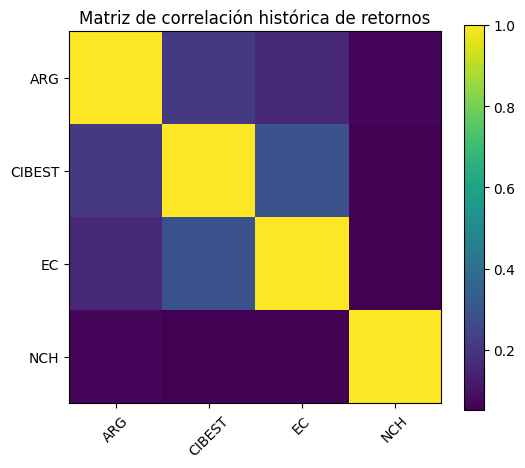

In [69]:
def build_correlation_adjacency(df, threshold=0.20):
    """
    Construye matriz de adyacencia usando correlación histórica de retornos.
    """
    pivot_returns = df.pivot_table(
        index="fecha",
        columns="stock",
        values="return_1d"
    ).sort_index()

    corr = pivot_returns.corr().fillna(0)

    stocks = corr.columns.tolist()

    adj = corr.abs().values

    # Eliminar conexiones débiles
    adj = np.where(adj >= threshold, adj, 0)

    # Mantener autoconexiones
    np.fill_diagonal(adj, 1)

    # Normalización simétrica A_hat = D^-1/2 A D^-1/2
    degree = adj.sum(axis=1)
    degree_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
    adj_norm = degree_inv_sqrt @ adj @ degree_inv_sqrt

    return stocks, corr, adj_norm


stocks_graph, corr_matrix, adj_norm = build_correlation_adjacency(
    train_df,
    threshold=0.20
)

print("Stocks grafo:", stocks_graph)
display(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix.values)
plt.colorbar()
plt.xticks(range(len(stocks_graph)), stocks_graph, rotation=45)
plt.yticks(range(len(stocks_graph)), stocks_graph)
plt.title("Matriz de correlación histórica de retornos")
plt.show()

## 16 - Dataset para GNN

In [70]:
def build_panel_tensor(df, features, stocks_order):
    """
    Construye panel temporal:
    fechas x stocks x features.
    """
    df = df.copy()
    df = df[df["stock"].isin(stocks_order)]

    dates = sorted(df["fecha"].unique())

    X_list = []
    y_list = []
    valid_dates = []

    for fecha in dates:
        day = df[df["fecha"] == fecha].set_index("stock")

        if not all(stock in day.index for stock in stocks_order):
            continue

        X_day = day.loc[stocks_order, features].values
        y_day = day.loc[stocks_order, "target"].values

        X_list.append(X_day)
        y_list.append(y_day)
        valid_dates.append(fecha)

    X_panel = np.array(X_list)
    y_panel = np.array(y_list)
    valid_dates = pd.to_datetime(valid_dates)

    return X_panel, y_panel, valid_dates


def build_gnn_sequences(df, features, stocks_order, lookback=20):
    X_panel, y_panel, dates = build_panel_tensor(df, features, stocks_order)

    X_seq = []
    y_seq = []
    date_seq = []

    for i in range(lookback, len(dates)):
        X_seq.append(X_panel[i - lookback:i])
        y_seq.append(y_panel[i])
        date_seq.append(dates[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    date_seq = pd.to_datetime(date_seq)

    return X_seq, y_seq, date_seq


class GNNSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def scale_gnn_data(X_train, X_val):
    """
    X shape: samples, lookback, nodes, features.
    """
    n, t, nodes, f = X_train.shape

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, f))

    X_train_scaled = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler

## 17 - Building GNN + LSTM

In [71]:
class ManualGraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        """
        x: batch, nodes, features
        adj: nodes, nodes
        """
        x_graph = torch.einsum("ij,bjf->bif", adj, x)
        return self.linear(x_graph)


class GNNLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_nodes, adj_matrix, gnn_hidden=32, lstm_hidden=64, dropout=0.25):
        super().__init__()

        self.register_buffer(
            "adj",
            torch.tensor(adj_matrix, dtype=torch.float32)
        )

        self.gcn = ManualGraphConv(n_features, gnn_hidden)

        self.lstm = nn.LSTM(
            input_size=gnn_hidden,
            hidden_size=lstm_hidden,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

        self.n_nodes = n_nodes

    def forward(self, x):
        """
        x: batch, lookback, nodes, features
        output: batch, nodes
        """
        batch_size, lookback, n_nodes, n_features = x.shape

        node_outputs = []

        for node_idx in range(n_nodes):
            node_seq = []

            for t in range(lookback):
                x_t = x[:, t, :, :]               # batch, nodes, features
                h_t = torch.relu(self.gcn(x_t, self.adj))  # batch, nodes, gnn_hidden
                node_seq.append(h_t[:, node_idx, :])

            node_seq = torch.stack(node_seq, dim=1)  # batch, lookback, gnn_hidden

            lstm_out, _ = self.lstm(node_seq)
            last_hidden = lstm_out[:, -1, :]

            logit = self.classifier(last_hidden).squeeze(1)
            node_outputs.append(logit)

        logits = torch.stack(node_outputs, dim=1)  # batch, nodes
        return logits


def train_gnn_lstm(model, train_loader, val_loader, epochs=25, lr=1e-3, patience=5):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        probs_all = []
        true_all = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                probs = torch.sigmoid(logits).detach().cpu().numpy()

                val_losses.append(loss.item())
                probs_all.extend(probs.reshape(-1))
                true_all.extend(y_batch.detach().cpu().numpy().reshape(-1))

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        y_prob = np.array(probs_all)
        y_true = np.array(true_all).astype(int)

        thr, _ = find_best_threshold(y_true, y_prob, metric="mcc")
        y_pred = (y_prob >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mcc": mcc,
            "threshold": thr
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MCC: {mcc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping activado.")
            break

    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_gnn_lstm(model, loader):
    model.eval()

    probs_all = []
    true_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            probs = torch.sigmoid(logits).detach().cpu().numpy()

            probs_all.extend(probs.reshape(-1))
            true_all.extend(y_batch.numpy().reshape(-1))

    return np.array(true_all).astype(int), np.array(probs_all)

## 18 - Training GNN+LSTM

In [72]:
X_train_gnn, y_train_gnn, dates_train_gnn = build_gnn_sequences(
    train_df,
    FEATURES_EMBEDDINGS_ROLLING,
    stocks_order=stocks_graph,
    lookback=LOOKBACK_DAYS
)

X_val_gnn, y_val_gnn, dates_val_gnn = build_gnn_sequences(
    val_df,
    FEATURES_EMBEDDINGS_ROLLING,
    stocks_order=stocks_graph,
    lookback=LOOKBACK_DAYS
)

print("X_train_gnn:", X_train_gnn.shape)
print("y_train_gnn:", y_train_gnn.shape)

print("X_val_gnn:", X_val_gnn.shape)
print("y_val_gnn:", y_val_gnn.shape)

X_train_gnn, X_val_gnn, gnn_scaler = scale_gnn_data(X_train_gnn, X_val_gnn)

train_gnn_dataset = GNNSequenceDataset(X_train_gnn, y_train_gnn)
val_gnn_dataset = GNNSequenceDataset(X_val_gnn, y_val_gnn)

train_gnn_loader = DataLoader(train_gnn_dataset, batch_size=32, shuffle=True)
val_gnn_loader = DataLoader(val_gnn_dataset, batch_size=32, shuffle=False)

gnn_lstm_model = GNNLSTMClassifier(
    n_features=X_train_gnn.shape[-1],
    n_nodes=len(stocks_graph),
    adj_matrix=adj_norm,
    gnn_hidden=32,
    lstm_hidden=64,
    dropout=0.25
)

gnn_lstm_model, gnn_history = train_gnn_lstm(
    model=gnn_lstm_model,
    train_loader=train_gnn_loader,
    val_loader=val_gnn_loader,
    epochs=EPOCHS_DL,
    lr=LEARNING_RATE_DL,
    patience=PATIENCE_DL
)

y_true_gnn, y_prob_gnn = predict_gnn_lstm(gnn_lstm_model, val_gnn_loader)

best_thr_gnn, _ = find_best_threshold(y_true_gnn, y_prob_gnn, metric="mcc")
y_pred_gnn = (y_prob_gnn >= best_thr_gnn).astype(int)

gnn_metrics = compute_metrics(y_true_gnn, y_pred_gnn, y_prob_gnn)
gnn_metrics.update({
    "modelo": "GNN_LSTM",
    "escenario": "C_tecnicas_embeddings_rolling5",
    "threshold": best_thr_gnn,
    "n_features": len(FEATURES_EMBEDDINGS_ROLLING),
    "tipo_modelo": "GNN_Deep_Learning"
})

gnn_results_df = pd.DataFrame([gnn_metrics])
display(gnn_results_df)

X_train_gnn: (684, 20, 4, 790)
y_train_gnn: (684, 4)
X_val_gnn: (218, 20, 4, 790)
y_val_gnn: (218, 4)
Epoch 01 | Train Loss: 0.6837 | Val Loss: 0.6730 | Val MCC: 0.1632
Epoch 02 | Train Loss: 0.6767 | Val Loss: 0.6768 | Val MCC: 0.1261
Epoch 03 | Train Loss: 0.6722 | Val Loss: 0.6811 | Val MCC: 0.1202
Epoch 04 | Train Loss: 0.6702 | Val Loss: 0.6820 | Val MCC: 0.1031
Epoch 05 | Train Loss: 0.6676 | Val Loss: 0.6873 | Val MCC: 0.1179
Epoch 06 | Train Loss: 0.6645 | Val Loss: 0.6824 | Val MCC: 0.1272
Early stopping activado.


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo
0,0.583716,0.558611,0.431925,0.127206,0.563773,GNN_LSTM,C_tecnicas_embeddings_rolling5,0.51,790,GNN_Deep_Learning


# RESUMEN GENERAL MODELOS

## 19 - Resumen resultados

In [73]:
all_results_df = pd.concat(
    [
        classic_results_df,
        deep_results_df,
        gnn_results_df
    ],
    ignore_index=True
)

all_results_df = all_results_df.sort_values(
    ["mcc", "accuracy"],
    ascending=False
).reset_index(drop=True)

display(all_results_df)

best_row = all_results_df.iloc[0]

BEST_MODEL_NAME = best_row["modelo"]
BEST_SCENARIO = best_row["escenario"]
BEST_THRESHOLD = best_row["threshold"]
BEST_MODEL_TYPE = best_row["tipo_modelo"]

print("======================================")
print("MEJOR MODELO EN VALIDACIÓN")
print("======================================")
print("Modelo:", BEST_MODEL_NAME)
print("Escenario:", BEST_SCENARIO)
print("Tipo:", BEST_MODEL_TYPE)
print("Threshold:", BEST_THRESHOLD)
print("Accuracy:", best_row["accuracy"])
print("MCC:", best_row["mcc"])

,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo
0,0.523952,0.569464,0.625295,0.186116,0.574348,Logistic_Regression,A_tecnicas,0.34,9,Clasico
1,0.536926,0.574506,0.617162,0.176993,0.587760,Gradient_Boosting,A_tecnicas,0.30,9,Clasico
2,0.583832,0.576884,0.522337,0.153647,0.583938,Random_Forest,A_tecnicas,0.45,9,Clasico
3,0.568862,0.576501,0.560976,0.152369,0.599013,XGBoost,A_tecnicas,0.40,9,Clasico
4,0.533932,0.565438,0.599829,0.146204,0.553855,XGBoost,C_tecnicas_embeddings_rolling5,0.34,790,Clasico
5,0.583716,0.558611,0.431925,0.127206,0.563773,GNN_LSTM,C_tecnicas_embeddings_rolling5,0.51,790,GNN_Deep_Learning
6,0.529940,0.558165,0.587927,0.126629,0.552267,Gradient_Boosting,C_tecnicas_embeddings_rolling5,0.36,790,Clasico
7,0.513972,0.552083,0.600492,0.125134,0.548647,Random_Forest,C_tecnicas_embeddings_rolling5,0.37,790,Clasico
8,0.528200,0.550699,0.574780,0.107168,0.549817,LSTM,C_tecnicas_embeddings_rolling5,0.40,790,Deep_Learning
9,0.513972,0.544858,0.581974,0.099991,0.542456,Logistic_Regression,C_tecnicas_embeddings_rolling5,0.34,790,Clasico


MEJOR MODELO EN VALIDACIÓN
Modelo: Logistic_Regression
Escenario: A_tecnicas
Tipo: Clasico
Threshold: 0.34
Accuracy: 0.5239520958083832
MCC: 0.18611583251038735


## 20 - Gráficos

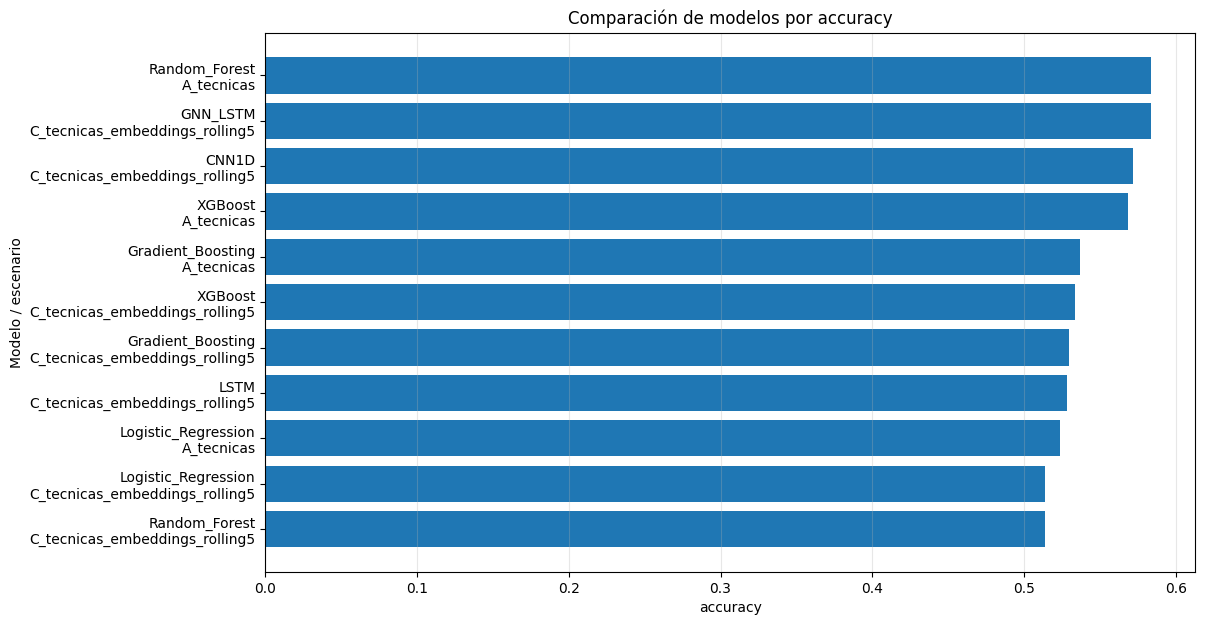

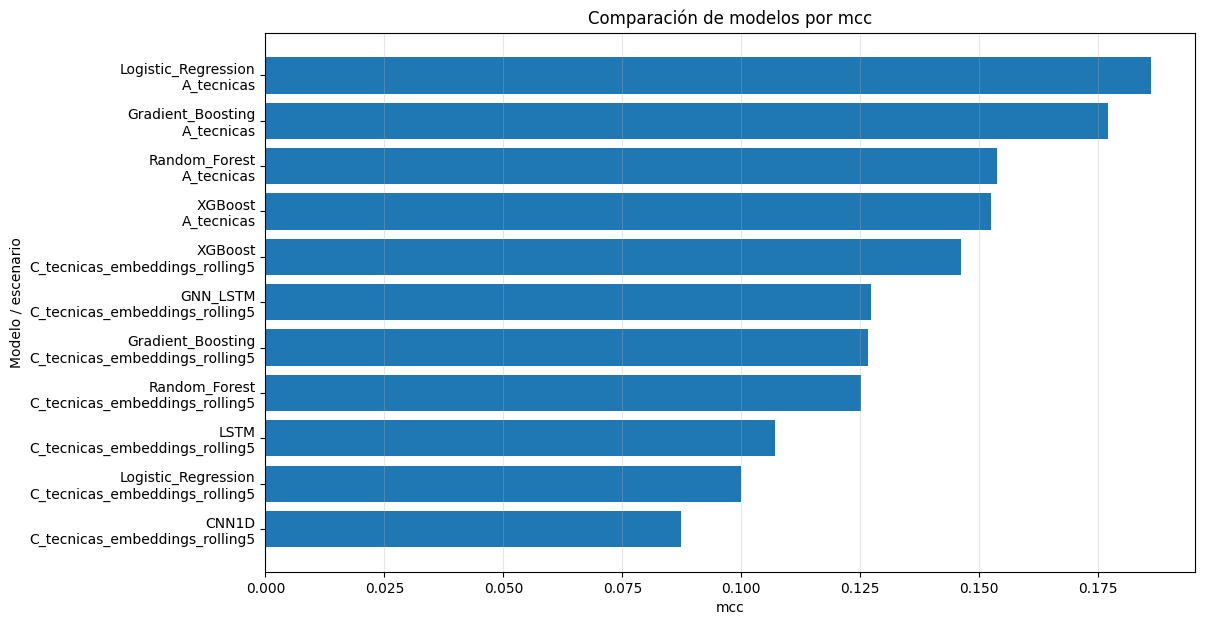

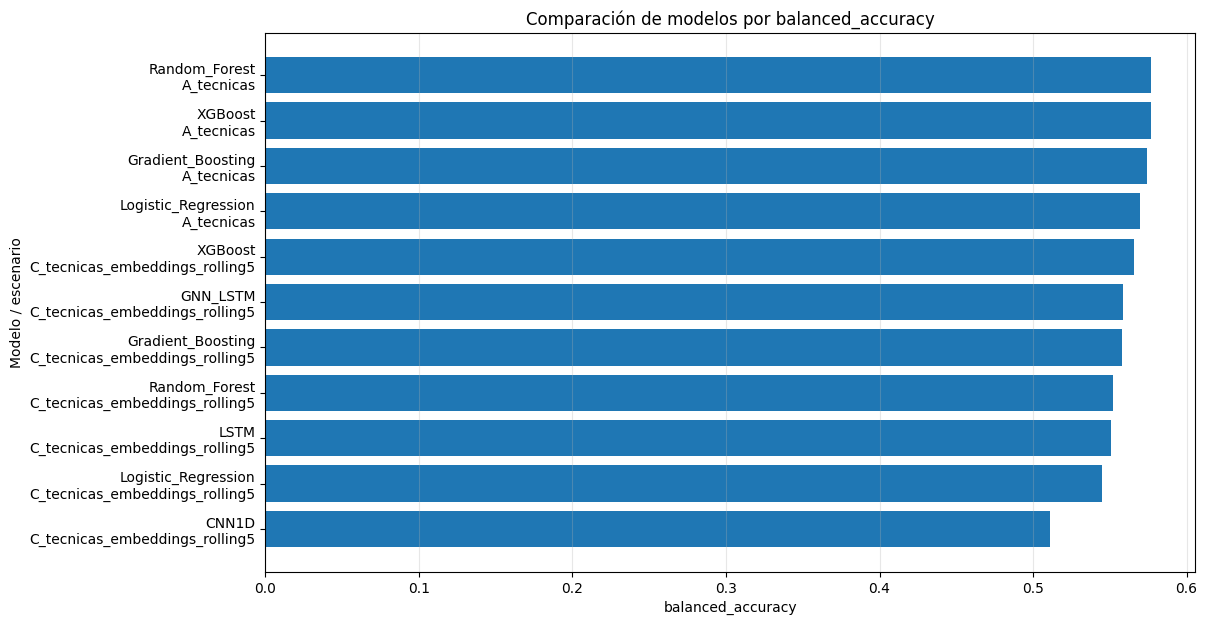

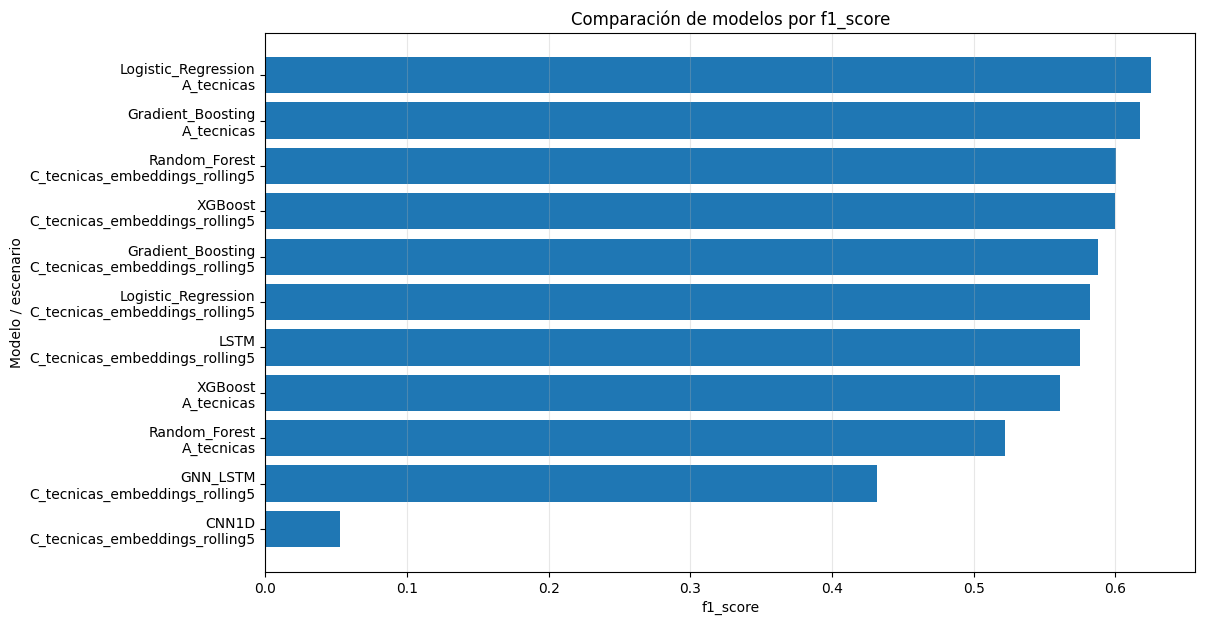

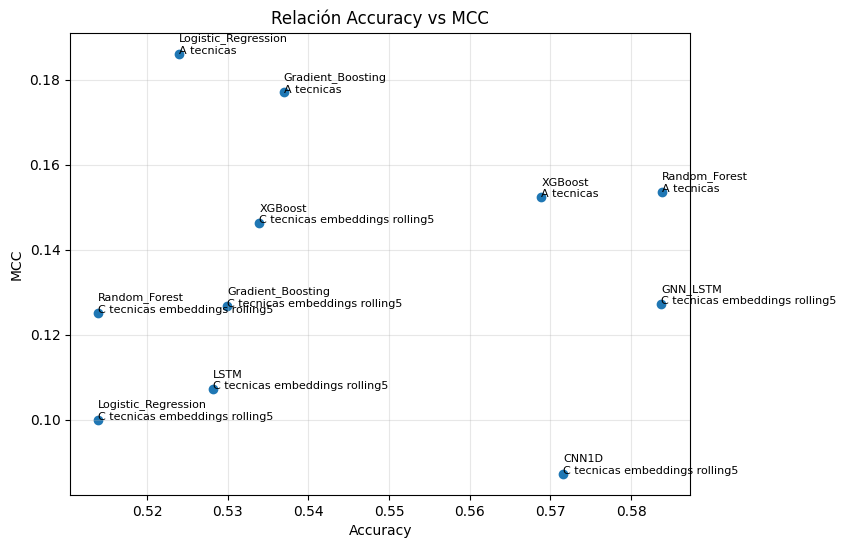

In [74]:
def plot_metric_comparison(results_df, metric):
    plot_df = results_df.copy()
    plot_df["modelo_final"] = plot_df["modelo"] + "\n" + plot_df["escenario"]

    plot_df = plot_df.sort_values(metric, ascending=True)

    plt.figure(figsize=(12, 7))
    plt.barh(plot_df["modelo_final"], plot_df[metric])
    plt.title(f"Comparación de modelos por {metric}")
    plt.xlabel(metric)
    plt.ylabel("Modelo / escenario")
    plt.grid(axis="x", alpha=0.3)
    plt.show()


plot_metric_comparison(all_results_df, "accuracy")
plot_metric_comparison(all_results_df, "mcc")
plot_metric_comparison(all_results_df, "balanced_accuracy")
plot_metric_comparison(all_results_df, "f1_score")

# Accuracy vs MCC
plt.figure(figsize=(8, 6))
plt.scatter(all_results_df["accuracy"], all_results_df["mcc"])

for _, row in all_results_df.iterrows():
    label = row["modelo"] + "\n" + row["escenario"].replace("_", " ")
    plt.annotate(label, (row["accuracy"], row["mcc"]), fontsize=8)

plt.title("Relación Accuracy vs MCC")
plt.xlabel("Accuracy")
plt.ylabel("MCC")
plt.grid(alpha=0.3)
plt.show()

# Prueba

## 21 - Rollin´ horizon 2025

In [83]:
# =========================================================
# BLOQUE 21. EVALUACIÓN ESTÁTICA EN 2025
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

# ---------------------------------------------------------
# 1. Validaciones base
# ---------------------------------------------------------

required_objects = [
    "dataset",
    "SCENARIOS",
    "get_classic_models",
    "compute_metrics",
    "find_best_threshold"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta primero los bloques anteriores.")

dataset = dataset.copy()
dataset["fecha"] = pd.to_datetime(dataset["fecha"])
dataset["target"] = dataset["target"].astype(int)

# Asegurar fechas como Timestamp
TEST_START = pd.to_datetime("2025-01-01")
TEST_END = pd.to_datetime("2025-12-31")

# ---------------------------------------------------------
# 2. Definir conjuntos temporales
# ---------------------------------------------------------

# Para evitar seleccionar threshold usando 2025:
# - Entrenamiento interno: antes de 2024
# - Validación interna: 2024
# - Test final: 2025
static_train_internal_df = dataset[dataset["fecha"] < "2024-01-01"].copy()

static_val_internal_df = dataset[
    (dataset["fecha"] >= "2024-01-01") &
    (dataset["fecha"] <= "2024-12-31")
].copy()

train_full_df = dataset[dataset["fecha"] < TEST_START].copy()

test_2025_df = dataset[
    (dataset["fecha"] >= TEST_START) &
    (dataset["fecha"] <= TEST_END)
].copy()

if test_2025_df.empty:
    raise ValueError("No hay datos disponibles para 2025 en dataset.")

print("Train interno threshold:", static_train_internal_df.shape)
print("Validación interna threshold:", static_val_internal_df.shape)
print("Train full 2021-2024:", train_full_df.shape)
print("Test 2025:", test_2025_df.shape)

# ---------------------------------------------------------
# 3. Evaluación estática
# ---------------------------------------------------------

static_2025_results = []
static_2025_predictions = []

for scenario_name, features in SCENARIOS.items():

    print("\n======================================")
    print(f"Escenario estático: {scenario_name}")
    print("Cantidad de features:", len(features))
    print("======================================")

    missing_features = [c for c in features if c not in dataset.columns]
    if missing_features:
        raise ValueError(
            f"Faltan features del escenario {scenario_name}: {missing_features[:50]}"
        )

    X_train_internal = static_train_internal_df[features]
    y_train_internal = static_train_internal_df["target"]

    X_val_internal = static_val_internal_df[features]
    y_val_internal = static_val_internal_df["target"]

    X_train_full = train_full_df[features]
    y_train_full = train_full_df["target"]

    X_test = test_2025_df[features]
    y_test = test_2025_df["target"]

    for model_name, model in get_classic_models().items():

        print(f"Entrenando modelo estático: {model_name}")

        pipe_threshold = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        # Entrenamiento interno para buscar threshold
        pipe_threshold.fit(X_train_internal, y_train_internal)
        y_prob_val = pipe_threshold.predict_proba(X_val_internal)[:, 1]

        best_threshold, best_threshold_score = find_best_threshold(
            y_true=y_val_internal,
            y_prob=y_prob_val,
            metric="mcc"
        )

        # Reentrenamiento final con todo 2021-2024
        final_model = get_classic_models()[model_name]

        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", final_model)
        ])

        pipe.fit(X_train_full, y_train_full)

        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= best_threshold).astype(int)

        metrics = compute_metrics(y_test, y_pred, y_prob)

        metrics.update({
            "modelo": model_name,
            "escenario": scenario_name,
            "tipo_evaluacion": "static_2025",
            "threshold": best_threshold,
            "threshold_mcc_val_2024": best_threshold_score,
            "n_features": len(features),
            "n_obs": len(y_test)
        })

        static_2025_results.append(metrics)

        tmp_pred = test_2025_df[["fecha", "stock", "target", "close"]].copy()
        tmp_pred["modelo"] = model_name
        tmp_pred["escenario"] = scenario_name
        tmp_pred["y_prob"] = y_prob
        tmp_pred["y_pred"] = y_pred
        tmp_pred["threshold"] = best_threshold

        static_2025_predictions.append(tmp_pred)

# ---------------------------------------------------------
# 4. Consolidar resultados
# ---------------------------------------------------------

static_2025_results_df = pd.DataFrame(static_2025_results)
static_2025_results_df = static_2025_results_df.sort_values(
    ["mcc", "accuracy"],
    ascending=False
).reset_index(drop=True)

static_2025_predictions_df = pd.concat(static_2025_predictions, ignore_index=True)

print("======================================")
print("RESULTADOS ESTÁTICOS 2025")
print("======================================")

display(static_2025_results_df)

print("Predicciones estáticas generadas:")
display(static_2025_predictions_df.head())

Train interno threshold: (3010, 1574)
Validación interna threshold: (1002, 1574)
Train full 2021-2024: (4012, 1574)
Test 2025: (996, 1574)

Escenario estático: A_tecnicas
Cantidad de features: 9
Entrenando modelo estático: Logistic_Regression
Entrenando modelo estático: Random_Forest
Entrenando modelo estático: Gradient_Boosting
Entrenando modelo estático: XGBoost

Escenario estático: C_tecnicas_embeddings_rolling5
Cantidad de features: 790
Entrenando modelo estático: Logistic_Regression
Entrenando modelo estático: Random_Forest
Entrenando modelo estático: Gradient_Boosting
Entrenando modelo estático: XGBoost
RESULTADOS ESTÁTICOS 2025


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,tipo_evaluacion,threshold,threshold_mcc_val_2024,n_features,n_obs
0,0.549197,0.565838,0.595131,0.138574,0.571068,Gradient_Boosting,C_tecnicas_embeddings_rolling5,static_2025,0.36,0.126629,790,996
1,0.548193,0.562729,0.586397,0.130177,0.587399,Logistic_Regression,C_tecnicas_embeddings_rolling5,static_2025,0.34,0.099991,790,996
2,0.544177,0.560869,0.590991,0.128208,0.575331,XGBoost,C_tecnicas_embeddings_rolling5,static_2025,0.34,0.146204,790,996
3,0.554217,0.559435,0.553320,0.118824,0.576795,XGBoost,A_tecnicas,static_2025,0.40,0.152369,9,996
4,0.528112,0.550832,0.598976,0.113405,0.576896,Gradient_Boosting,A_tecnicas,static_2025,0.30,0.176993,9,996
5,0.521084,0.543436,0.591959,0.096577,0.560991,Random_Forest,C_tecnicas_embeddings_rolling5,static_2025,0.37,0.125134,790,996
6,0.529116,0.544165,0.571689,0.092060,0.566931,Logistic_Regression,A_tecnicas,static_2025,0.34,0.186116,9,996
7,0.551205,0.545720,0.496054,0.091664,0.579706,Random_Forest,A_tecnicas,static_2025,0.45,0.153647,9,996


Predicciones estáticas generadas:


,fecha,stock,target,close,modelo,escenario,y_prob,y_pred,threshold
0,2025-01-02,ARG,1,19389.322266,Logistic_Regression,A_tecnicas,0.471553,1,0.34
1,2025-01-03,ARG,0,19541.033203,Logistic_Regression,A_tecnicas,0.464020,1,0.34
2,2025-01-07,ARG,0,19483.785156,Logistic_Regression,A_tecnicas,0.465268,1,0.34
3,2025-01-08,ARG,0,19235.705078,Logistic_Regression,A_tecnicas,0.471875,1,0.34
4,2025-01-09,ARG,1,19178.453125,Logistic_Regression,A_tecnicas,0.467881,1,0.34


## 22 - Reentrenamiento

In [84]:
# =========================================================
# BLOQUE 22. ROLLING HORIZON 2025 CON REENTRENAMIENTO
# =========================================================

# ---------------------------------------------------------
# 1. Validaciones base
# ---------------------------------------------------------

required_objects = [
    "dataset",
    "all_results_df",
    "SCENARIOS",
    "get_classic_models",
    "find_best_threshold"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta primero los bloques anteriores.")

dataset = dataset.copy()
dataset["fecha"] = pd.to_datetime(dataset["fecha"])
dataset["target"] = dataset["target"].astype(int)
dataset["stock"] = dataset["stock"].astype(str)

TEST_START = pd.to_datetime("2025-01-01")
TEST_END = pd.to_datetime("2025-12-31")

ROLLING_RETRAIN_EVERY_N_DAYS = 1
MIN_TRAIN_ROWS_ROLLING = 300

# ---------------------------------------------------------
# 2. Seleccionar mejor modelo clásico desde validación 2024
# ---------------------------------------------------------

classic_only_sorted = all_results_df[
    all_results_df["tipo_modelo"].astype(str).str.contains("Clasico", case=False, na=False)
].copy()

if classic_only_sorted.empty:
    raise ValueError(
        "No se encontraron modelos clásicos en all_results_df. "
        "Revisa la columna tipo_modelo."
    )

classic_only_sorted = classic_only_sorted.sort_values(
    ["mcc", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("======================================")
print("RANKING DE MODELOS CLÁSICOS PARA ROLLING")
print("======================================")
display(classic_only_sorted)

BEST_CLASSIC_ROW = classic_only_sorted.iloc[0]

ROLLING_MODEL_NAME = BEST_CLASSIC_ROW["modelo"]
ROLLING_SCENARIO = BEST_CLASSIC_ROW["escenario"]

if ROLLING_SCENARIO not in SCENARIOS:
    raise ValueError(
        f"El escenario {ROLLING_SCENARIO} no existe en SCENARIOS."
    )

ROLLING_FEATURES = SCENARIOS[ROLLING_SCENARIO]

missing_features = [c for c in ROLLING_FEATURES if c not in dataset.columns]

if missing_features:
    raise ValueError(
        f"Faltan features para rolling: {missing_features[:50]}"
    )

print("======================================")
print("MODELO SELECCIONADO PARA ROLLING")
print("======================================")
print("Modelo:", ROLLING_MODEL_NAME)
print("Escenario:", ROLLING_SCENARIO)
print("Features:", len(ROLLING_FEATURES))
print("MCC validación 2024:", BEST_CLASSIC_ROW["mcc"])
print("Accuracy validación 2024:", BEST_CLASSIC_ROW["accuracy"])

# ---------------------------------------------------------
# 3. Función de entrenamiento por fecha
# ---------------------------------------------------------

def train_classic_for_period(
    model_name,
    train_data,
    features,
    threshold_metric="mcc"
):
    """
    Entrena un modelo clásico usando únicamente datos anteriores
    a la fecha de predicción.
    """

    train_data = train_data.sort_values(["fecha", "stock"]).copy()

    if len(train_data) < 50:
        raise ValueError(f"Muy pocas filas para entrenar: {len(train_data)}")

    if train_data["target"].nunique() < 2:
        raise ValueError("El target tiene una sola clase en train_data.")

    split_idx = int(len(train_data) * 0.80)

    inner_train = train_data.iloc[:split_idx].copy()
    inner_val = train_data.iloc[split_idx:].copy()

    if len(inner_val) < 30 or inner_val["target"].nunique() < 2:
        inner_train = train_data.copy()
        inner_val = train_data.copy()

    X_train = inner_train[features]
    y_train = inner_train["target"]

    X_val = inner_val[features]
    y_val = inner_val["target"]

    model = get_classic_models()[model_name]

    pipe_threshold = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe_threshold.fit(X_train, y_train)

    y_prob_val = pipe_threshold.predict_proba(X_val)[:, 1]

    best_threshold, best_threshold_score = find_best_threshold(
        y_true=y_val,
        y_prob=y_prob_val,
        metric=threshold_metric
    )

    final_model = get_classic_models()[model_name]

    pipe_final = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", final_model)
    ])

    pipe_final.fit(train_data[features], train_data["target"])

    return pipe_final, best_threshold, best_threshold_score

# ---------------------------------------------------------
# 4. Función rolling horizon
# ---------------------------------------------------------

def rolling_horizon_2025(
    dataset,
    model_name,
    scenario_name,
    features,
    test_start,
    test_end,
    retrain_every_n_days=1,
    min_train_rows=300
):
    """
    Rolling horizon real.
    Para cada fecha de 2025:
    - Entrena con todo lo anterior.
    - Predice esa fecha.
    - Avanza al siguiente día disponible.
    """

    data = dataset.copy()
    data["fecha"] = pd.to_datetime(data["fecha"])
    data = data.sort_values(["fecha", "stock"]).reset_index(drop=True)

    prediction_dates = sorted(
        data[
            (data["fecha"] >= test_start) &
            (data["fecha"] <= test_end)
        ]["fecha"].unique()
    )

    if len(prediction_dates) == 0:
        raise ValueError("No hay fechas disponibles para predecir en 2025.")

    all_predictions = []

    current_model = None
    current_threshold = None
    current_threshold_score = None
    last_retrain_date = None

    retrain_count = 0
    skipped_dates = 0

    for i, current_date in enumerate(tqdm(prediction_dates, desc="Rolling horizon 2025")):

        current_date = pd.to_datetime(current_date)

        train_roll = data[data["fecha"] < current_date].copy()
        pred_roll = data[data["fecha"] == current_date].copy()

        if len(train_roll) < min_train_rows:
            skipped_dates += 1
            continue

        if pred_roll.empty:
            skipped_dates += 1
            continue

        if train_roll["target"].nunique() < 2:
            skipped_dates += 1
            continue

        should_retrain = (
            current_model is None or
            i % retrain_every_n_days == 0
        )

        if should_retrain:
            current_model, current_threshold, current_threshold_score = train_classic_for_period(
                model_name=model_name,
                train_data=train_roll,
                features=features,
                threshold_metric="mcc"
            )

            retrain_count += 1
            last_retrain_date = current_date

        X_pred = pred_roll[features]

        y_prob = current_model.predict_proba(X_pred)[:, 1]
        y_pred = (y_prob >= current_threshold).astype(int)

        tmp = pred_roll[["fecha", "stock", "target", "close"]].copy()

        tmp["y_prob"] = y_prob
        tmp["y_pred"] = y_pred
        tmp["threshold"] = current_threshold
        tmp["threshold_score_internal"] = current_threshold_score
        tmp["model"] = model_name
        tmp["scenario"] = scenario_name
        tmp["last_retrain_date"] = last_retrain_date
        tmp["train_rows_available"] = len(train_roll)

        all_predictions.append(tmp)

    if len(all_predictions) == 0:
        raise ValueError(
            "El rolling horizon no generó predicciones. "
            "Revisa fechas, min_train_rows o distribución del target."
        )

    rolling_pred_df = pd.concat(all_predictions, ignore_index=True)

    print("======================================")
    print("RESUMEN ROLLING HORIZON 2025")
    print("======================================")
    print("Fechas disponibles 2025:", len(prediction_dates))
    print("Fechas omitidas:", skipped_dates)
    print("Reentrenamientos realizados:", retrain_count)
    print("Predicciones generadas:", len(rolling_pred_df))
    print("Stocks predichos:", sorted(rolling_pred_df["stock"].unique()))
    print("Rango predicho:", rolling_pred_df["fecha"].min(), "->", rolling_pred_df["fecha"].max())

    return rolling_pred_df

# ---------------------------------------------------------
# 5. Ejecutar rolling
# ---------------------------------------------------------

rolling_pred_df = rolling_horizon_2025(
    dataset=dataset,
    model_name=ROLLING_MODEL_NAME,
    scenario_name=ROLLING_SCENARIO,
    features=ROLLING_FEATURES,
    test_start=TEST_START,
    test_end=TEST_END,
    retrain_every_n_days=ROLLING_RETRAIN_EVERY_N_DAYS,
    min_train_rows=MIN_TRAIN_ROWS_ROLLING
)

print("======================================")
print("rolling_pred_df creado correctamente")
print("======================================")
print("Shape:", rolling_pred_df.shape)

display(rolling_pred_df.head())
display(rolling_pred_df.tail())

RANKING DE MODELOS CLÁSICOS PARA ROLLING


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo
0,0.523952,0.569464,0.625295,0.186116,0.574348,Logistic_Regression,A_tecnicas,0.34,9,Clasico
1,0.536926,0.574506,0.617162,0.176993,0.587760,Gradient_Boosting,A_tecnicas,0.30,9,Clasico
2,0.583832,0.576884,0.522337,0.153647,0.583938,Random_Forest,A_tecnicas,0.45,9,Clasico
3,0.568862,0.576501,0.560976,0.152369,0.599013,XGBoost,A_tecnicas,0.40,9,Clasico
4,0.533932,0.565438,0.599829,0.146204,0.553855,XGBoost,C_tecnicas_embeddings_rolling5,0.34,790,Clasico
5,0.529940,0.558165,0.587927,0.126629,0.552267,Gradient_Boosting,C_tecnicas_embeddings_rolling5,0.36,790,Clasico
6,0.513972,0.552083,0.600492,0.125134,0.548647,Random_Forest,C_tecnicas_embeddings_rolling5,0.37,790,Clasico
7,0.513972,0.544858,0.581974,0.099991,0.542456,Logistic_Regression,C_tecnicas_embeddings_rolling5,0.34,790,Clasico


MODELO SELECCIONADO PARA ROLLING
Modelo: Logistic_Regression
Escenario: A_tecnicas
Features: 9
MCC validación 2024: 0.18611583251038735
Accuracy validación 2024: 0.5239520958083832


Rolling horizon 2025:   0%|          | 0/259 [00:00<?, ?it/s]

RESUMEN ROLLING HORIZON 2025
Fechas disponibles 2025: 259
Fechas omitidas: 0
Reentrenamientos realizados: 259
Predicciones generadas: 996
Stocks predichos: ['ARG', 'CIBEST', 'EC', 'NCH']
Rango predicho: 2025-01-02 00:00:00 -> 2025-12-31 00:00:00
rolling_pred_df creado correctamente
Shape: (996, 12)


,fecha,stock,target,close,y_prob,y_pred,threshold,threshold_score_internal,model,scenario,last_retrain_date,train_rows_available
0,2025-01-02,ARG,1,19389.322266,0.471553,1,0.42,0.172532,Logistic_Regression,A_tecnicas,2025-01-02,4012
1,2025-01-02,CIBEST,1,33862.910156,0.443029,1,0.42,0.172532,Logistic_Regression,A_tecnicas,2025-01-02,4012
2,2025-01-02,EC,1,7.416934,0.539669,1,0.42,0.172532,Logistic_Regression,A_tecnicas,2025-01-02,4012
3,2025-01-02,NCH,1,79000.000000,0.236866,0,0.42,0.172532,Logistic_Regression,A_tecnicas,2025-01-02,4012
4,2025-01-03,ARG,0,19541.033203,0.464891,1,0.41,0.172242,Logistic_Regression,A_tecnicas,2025-01-03,4016


,fecha,stock,target,close,y_prob,y_pred,threshold,threshold_score_internal,model,scenario,last_retrain_date,train_rows_available
991,2025-12-30,EC,1,9.870000,0.511575,1,0.3,0.139566,Logistic_Regression,A_tecnicas,2025-12-30,5001
992,2025-12-30,NCH,0,282000.000000,0.209248,0,0.3,0.139566,Logistic_Regression,A_tecnicas,2025-12-30,5001
993,2025-12-31,ARG,0,16614.314453,0.499414,1,0.3,0.140288,Logistic_Regression,A_tecnicas,2025-12-31,5005
994,2025-12-31,EC,0,10.020000,0.509510,1,0.3,0.140288,Logistic_Regression,A_tecnicas,2025-12-31,5005
995,2025-12-31,NCH,0,282000.000000,0.207015,0,0.3,0.140288,Logistic_Regression,A_tecnicas,2025-12-31,5005


## 23 - Evaluación prueba

MÉTRICAS GLOBALES - ROLLING HORIZON 2025


,modelo,escenario,tipo_evaluacion,n_obs,fecha_min,fecha_max,target_1_rate,pred_1_rate,accuracy,balanced_accuracy,f1_score,mcc,roc_auc
0,Logistic_Regression,A_tecnicas,rolling_horizon_2025,996,2025-01-02,2025-12-31,0.450803,0.753012,0.529116,0.554539,0.608841,0.125851,0.562693


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Baja       0.66      0.30      0.41       547
        Sube       0.49      0.81      0.61       449

    accuracy                           0.53       996
   macro avg       0.57      0.55      0.51       996
weighted avg       0.58      0.53      0.50       996



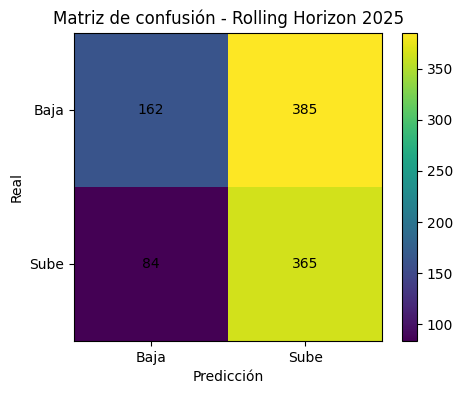

MÉTRICAS POR STOCK - ROLLING HORIZON 2025


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,stock,n_obs,fecha_min,fecha_max,target_1_rate,pred_1_rate
0,0.653386,0.502537,0.043956,0.017234,0.510078,NCH,251,2025-01-02,2025-12-31,0.342629,0.01992
1,0.532000,0.500000,0.694517,0.000000,0.505752,EC,250,2025-01-02,2025-12-31,0.532000,1.00000
2,0.508197,0.500000,0.673913,0.000000,0.525941,CIBEST,244,2025-01-02,2025-12-30,0.508197,1.00000
3,0.422311,0.500000,0.593838,0.000000,0.556018,ARG,251,2025-01-02,2025-12-31,0.422311,1.00000


MÉTRICAS POR MES - ROLLING HORIZON 2025


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,year_month,n_obs,target_1_rate,pred_1_rate
0,0.566265,0.587719,0.640000,0.201056,0.650877,2025-01,83,0.457831,0.746988
1,0.455696,0.472008,0.556701,-0.065364,0.476190,2025-02,79,0.468354,0.759494
2,0.566265,0.575291,0.647059,0.173073,0.603488,2025-03,83,0.481928,0.746988
3,0.470588,0.507653,0.545455,0.017268,0.516440,2025-04,85,0.423529,0.741176
4,0.534884,0.540584,0.622642,0.092991,0.627165,2025-05,86,0.488372,0.744186
5,0.526316,0.590609,0.581395,0.203299,0.636831,2025-06,76,0.381579,0.750000
6,0.538462,0.607843,0.588235,0.240094,0.554180,2025-07,91,0.373626,0.747253
7,0.612500,0.606316,0.693069,0.245451,0.655410,2025-08,80,0.512500,0.750000
8,0.540230,0.587418,0.607843,0.201227,0.611656,2025-09,87,0.413793,0.758621
9,0.494382,0.465051,0.621849,-0.084853,0.441327,2025-10,89,0.550562,0.786517


In [85]:
# =========================================================
# BLOQUE 23. EVALUACIÓN DEL ROLLING HORIZON 2025
# =========================================================

# ---------------------------------------------------------
# 1. Validar rolling_pred_df
# ---------------------------------------------------------

if "rolling_pred_df" not in globals():
    raise NameError(
        "No existe rolling_pred_df. Ejecuta primero el Bloque 22."
    )

if rolling_pred_df.empty:
    raise ValueError(
        "rolling_pred_df está vacío. El rolling no generó predicciones."
    )

required_cols = ["fecha", "stock", "target", "y_pred", "y_prob"]

missing_cols = [c for c in required_cols if c not in rolling_pred_df.columns]

if missing_cols:
    raise ValueError(
        f"rolling_pred_df no tiene las columnas necesarias: {missing_cols}"
    )

rolling_pred_df["fecha"] = pd.to_datetime(rolling_pred_df["fecha"])
rolling_pred_df["target"] = rolling_pred_df["target"].astype(int)
rolling_pred_df["y_pred"] = rolling_pred_df["y_pred"].astype(int)
rolling_pred_df["y_prob"] = rolling_pred_df["y_prob"].astype(float)

# ---------------------------------------------------------
# 2. Métricas globales
# ---------------------------------------------------------

rolling_metrics = compute_metrics(
    y_true=rolling_pred_df["target"],
    y_pred=rolling_pred_df["y_pred"],
    y_prob=rolling_pred_df["y_prob"]
)

rolling_metrics_df = pd.DataFrame([{
    "modelo": ROLLING_MODEL_NAME,
    "escenario": ROLLING_SCENARIO,
    "tipo_evaluacion": "rolling_horizon_2025",
    "n_obs": len(rolling_pred_df),
    "fecha_min": rolling_pred_df["fecha"].min(),
    "fecha_max": rolling_pred_df["fecha"].max(),
    "target_1_rate": rolling_pred_df["target"].mean(),
    "pred_1_rate": rolling_pred_df["y_pred"].mean(),
    **rolling_metrics
}])

print("======================================")
print("MÉTRICAS GLOBALES - ROLLING HORIZON 2025")
print("======================================")

display(rolling_metrics_df)

print("======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(classification_report(
    rolling_pred_df["target"],
    rolling_pred_df["y_pred"],
    labels=[0, 1],
    target_names=["Baja", "Sube"],
    zero_division=0
))

# ---------------------------------------------------------
# 3. Matriz de confusión
# ---------------------------------------------------------

plot_confusion_matrix_simple(
    rolling_pred_df["target"],
    rolling_pred_df["y_pred"],
    title="Matriz de confusión - Rolling Horizon 2025"
)

# ---------------------------------------------------------
# 4. Métricas por stock
# ---------------------------------------------------------

rolling_metrics_by_stock = []

for stock, g in rolling_pred_df.groupby("stock"):

    m = compute_metrics(
        y_true=g["target"],
        y_pred=g["y_pred"],
        y_prob=g["y_prob"]
    )

    m["stock"] = stock
    m["n_obs"] = len(g)
    m["fecha_min"] = g["fecha"].min()
    m["fecha_max"] = g["fecha"].max()
    m["target_1_rate"] = g["target"].mean()
    m["pred_1_rate"] = g["y_pred"].mean()

    rolling_metrics_by_stock.append(m)

rolling_metrics_by_stock_df = pd.DataFrame(rolling_metrics_by_stock)
rolling_metrics_by_stock_df = rolling_metrics_by_stock_df.sort_values(
    ["mcc", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("======================================")
print("MÉTRICAS POR STOCK - ROLLING HORIZON 2025")
print("======================================")

display(rolling_metrics_by_stock_df)

# ---------------------------------------------------------
# 5. Métricas por mes
# ---------------------------------------------------------

rolling_pred_df["year_month"] = rolling_pred_df["fecha"].dt.to_period("M").astype(str)

rolling_metrics_by_month = []

for month, g in rolling_pred_df.groupby("year_month"):

    if len(g) < 5:
        continue

    m = compute_metrics(
        y_true=g["target"],
        y_pred=g["y_pred"],
        y_prob=g["y_prob"]
    )

    m["year_month"] = month
    m["n_obs"] = len(g)
    m["target_1_rate"] = g["target"].mean()
    m["pred_1_rate"] = g["y_pred"].mean()

    rolling_metrics_by_month.append(m)

rolling_metrics_by_month_df = pd.DataFrame(rolling_metrics_by_month)

print("======================================")
print("MÉTRICAS POR MES - ROLLING HORIZON 2025")
print("======================================")

display(rolling_metrics_by_month_df)

## 24 - Gráfica rollin´ horizon

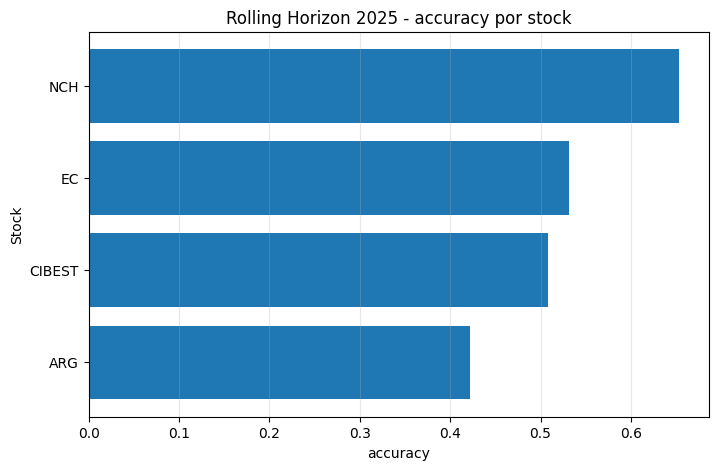

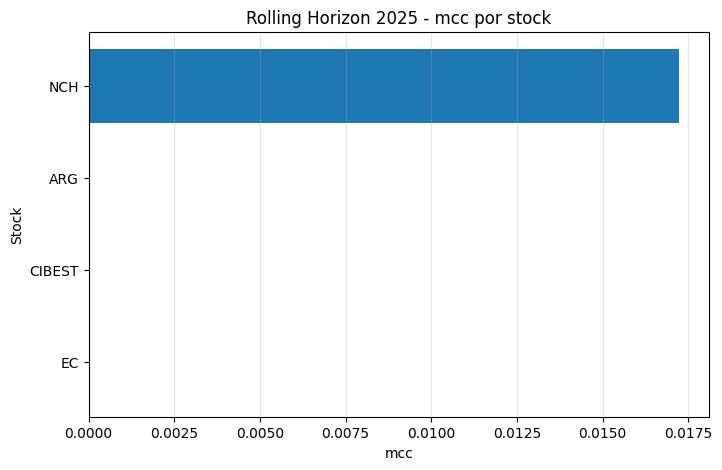

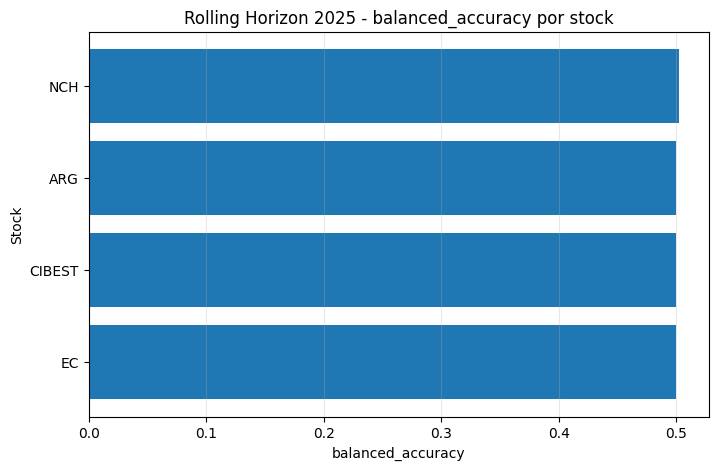

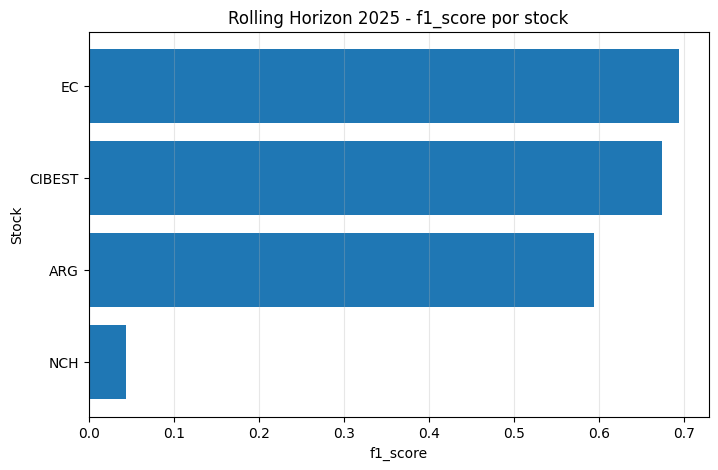

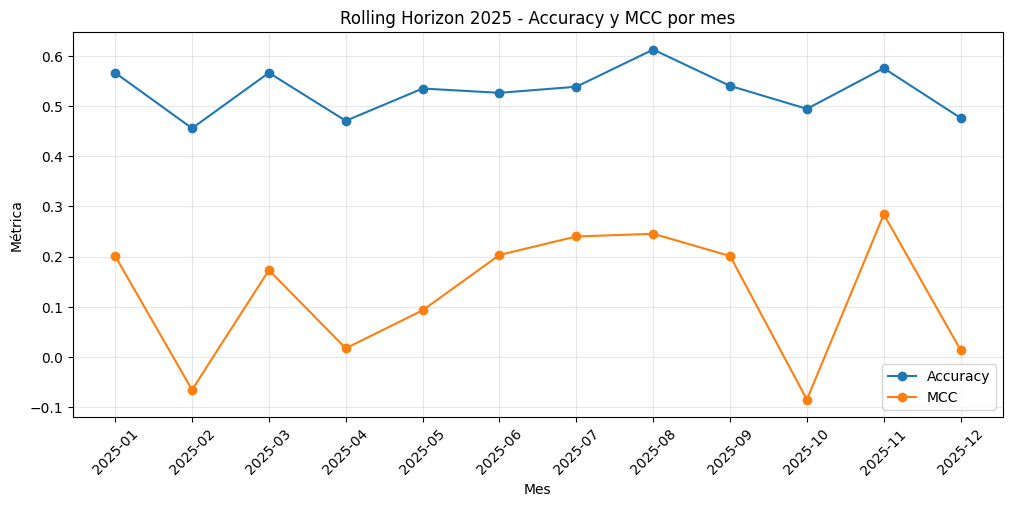

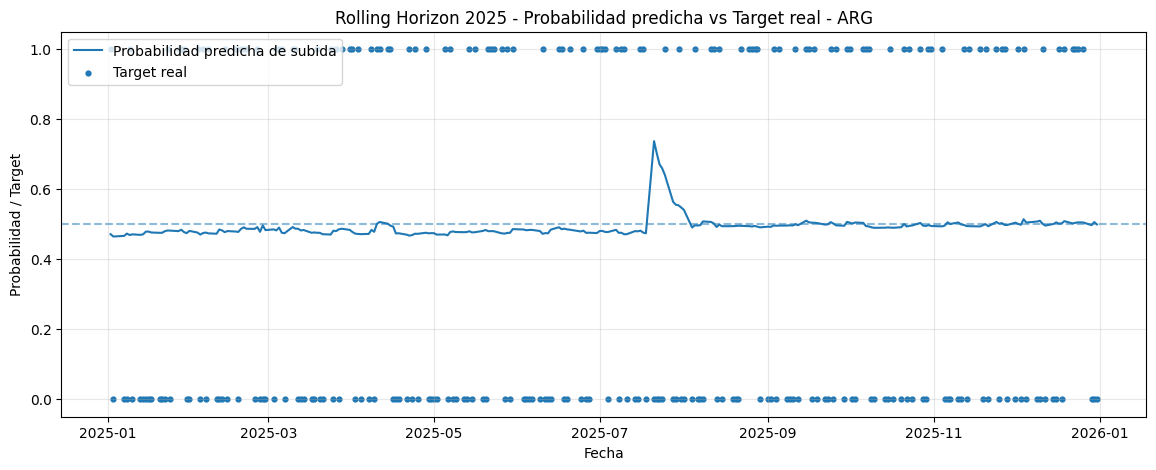

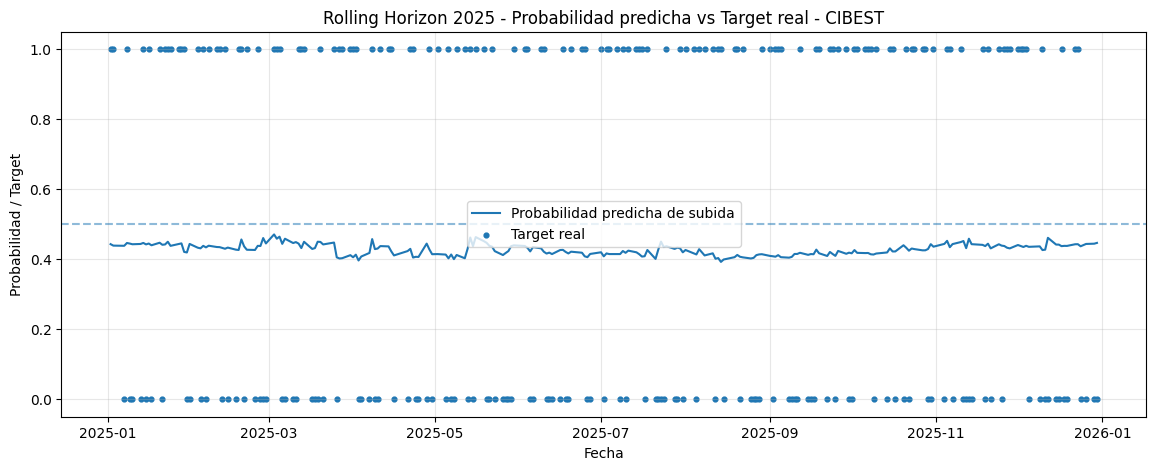

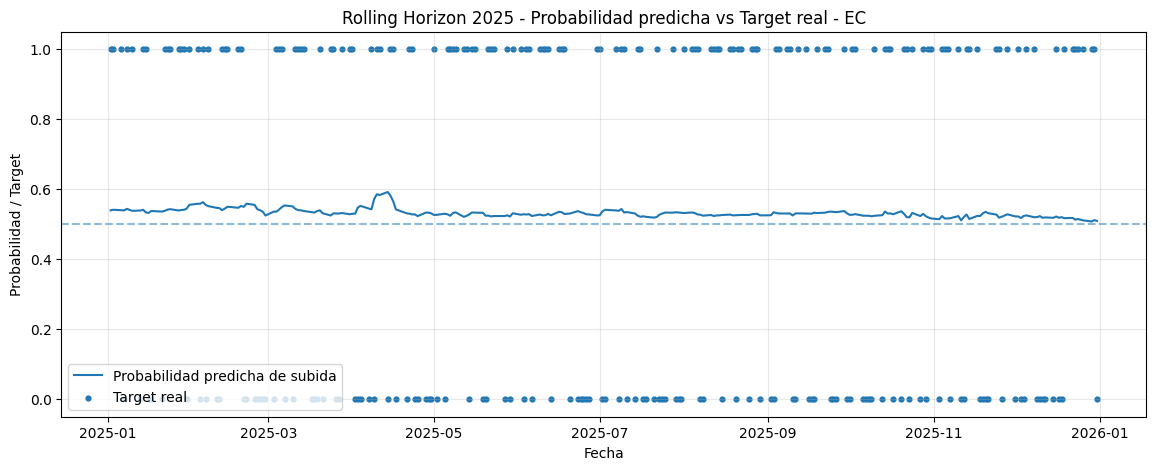

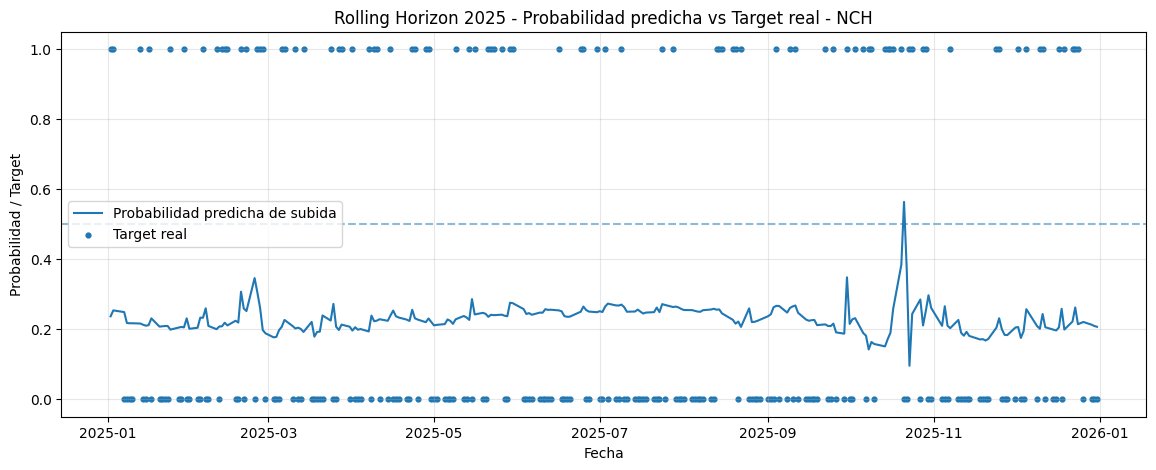

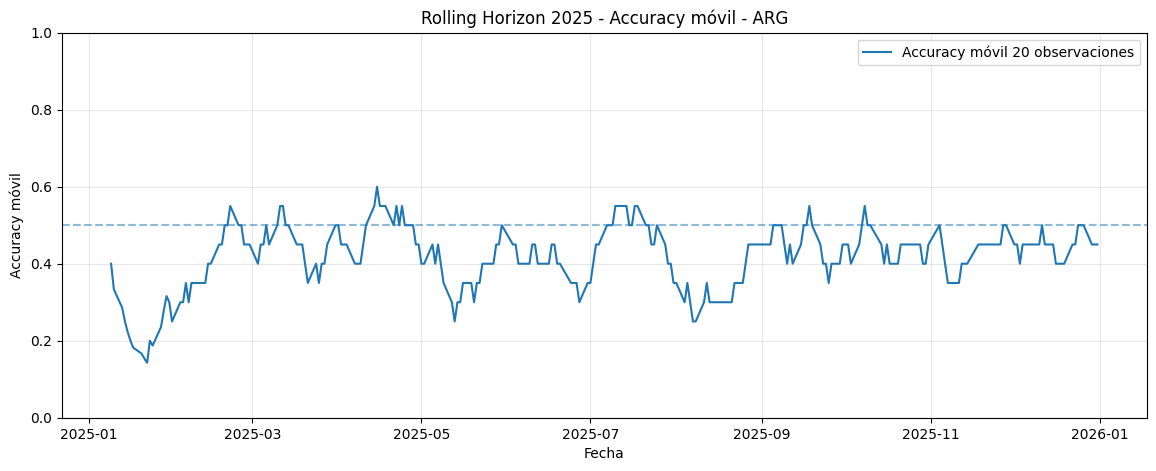

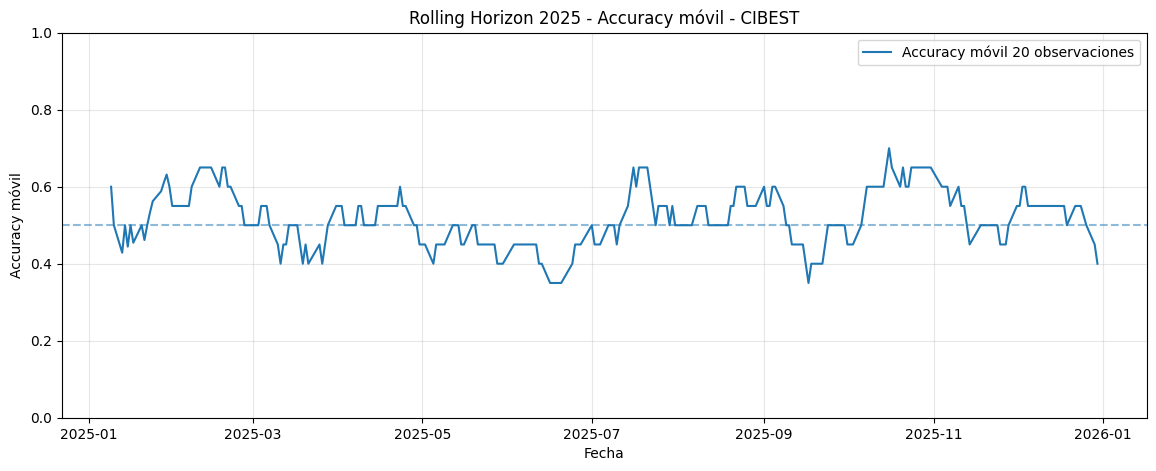

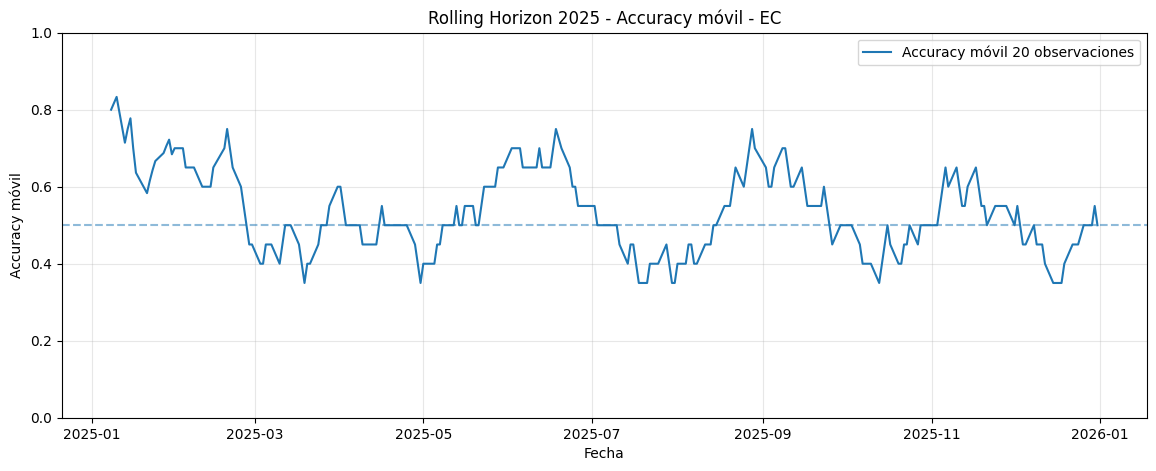

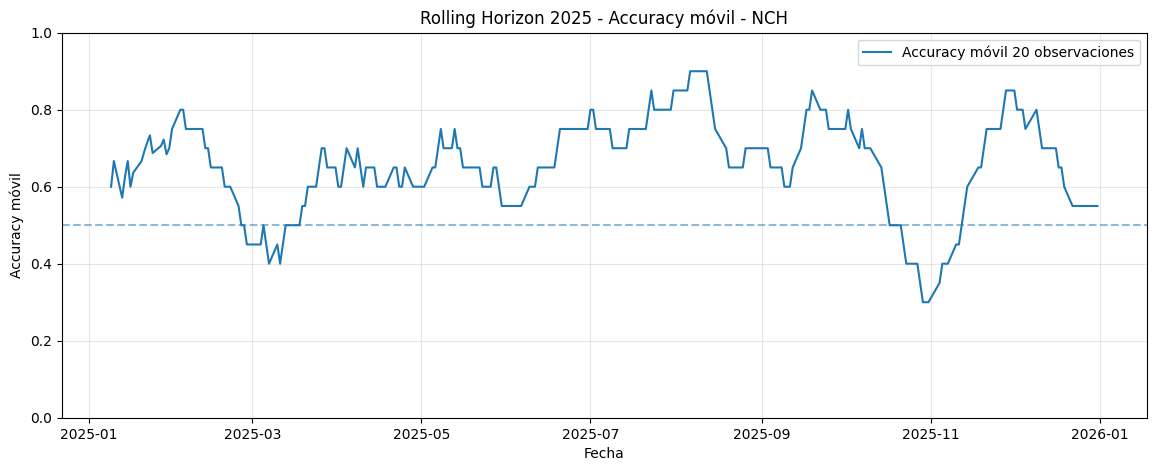

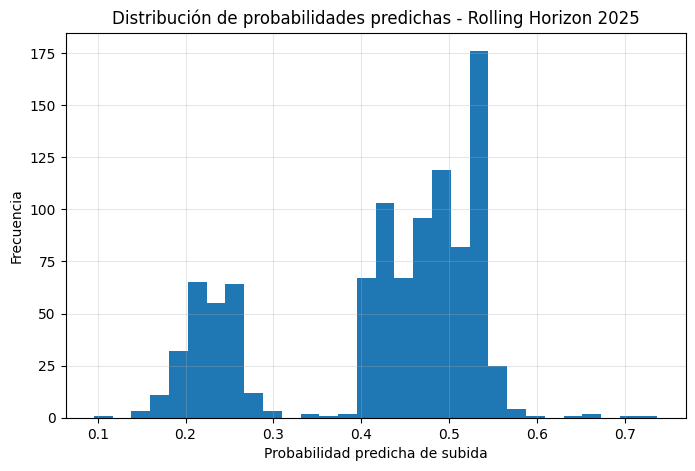

,variable,proporcion
0,target_real_1_rate,0.450803
1,prediccion_1_rate,0.753012


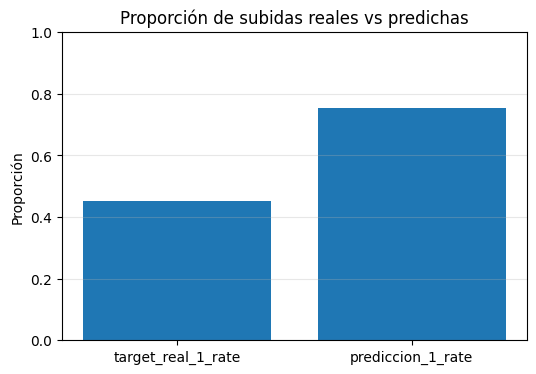

In [86]:
# =========================================================
# BLOQUE 24. GRÁFICAS DEL ROLLING HORIZON 2025
# =========================================================

# ---------------------------------------------------------
# 1. Validaciones
# ---------------------------------------------------------

required_objects = [
    "rolling_pred_df",
    "rolling_metrics_by_stock_df",
    "rolling_metrics_by_month_df"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta primero el Bloque 23.")

# ---------------------------------------------------------
# 2. Métricas por stock
# ---------------------------------------------------------

for metric in ["accuracy", "mcc", "balanced_accuracy", "f1_score"]:

    if metric not in rolling_metrics_by_stock_df.columns:
        continue

    plot_df = rolling_metrics_by_stock_df.sort_values(metric, ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["stock"], plot_df[metric])
    plt.title(f"Rolling Horizon 2025 - {metric} por stock")
    plt.xlabel(metric)
    plt.ylabel("Stock")
    plt.grid(axis="x", alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# 3. Accuracy y MCC por mes
# ---------------------------------------------------------

if not rolling_metrics_by_month_df.empty:

    plt.figure(figsize=(12, 5))

    plt.plot(
        rolling_metrics_by_month_df["year_month"],
        rolling_metrics_by_month_df["accuracy"],
        marker="o",
        label="Accuracy"
    )

    plt.plot(
        rolling_metrics_by_month_df["year_month"],
        rolling_metrics_by_month_df["mcc"],
        marker="o",
        label="MCC"
    )

    plt.title("Rolling Horizon 2025 - Accuracy y MCC por mes")
    plt.xlabel("Mes")
    plt.ylabel("Métrica")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("No hay métricas mensuales suficientes para graficar.")

# ---------------------------------------------------------
# 4. Probabilidad predicha vs target real por stock
# ---------------------------------------------------------

for stock, g in rolling_pred_df.groupby("stock"):

    g = g.sort_values("fecha").copy()

    plt.figure(figsize=(14, 5))

    plt.plot(
        g["fecha"],
        g["y_prob"],
        label="Probabilidad predicha de subida"
    )

    plt.scatter(
        g["fecha"],
        g["target"],
        label="Target real",
        s=12
    )

    plt.axhline(0.5, linestyle="--", alpha=0.5)

    plt.title(f"Rolling Horizon 2025 - Probabilidad predicha vs Target real - {stock}")
    plt.xlabel("Fecha")
    plt.ylabel("Probabilidad / Target")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# 5. Accuracy móvil por stock
# ---------------------------------------------------------

rolling_pred_df["correct"] = (
    rolling_pred_df["target"] == rolling_pred_df["y_pred"]
).astype(int)

for stock, g in rolling_pred_df.groupby("stock"):

    g = g.sort_values("fecha").copy()

    g["rolling_accuracy_20"] = (
        g["correct"]
        .rolling(window=20, min_periods=5)
        .mean()
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        g["fecha"],
        g["rolling_accuracy_20"],
        label="Accuracy móvil 20 observaciones"
    )

    plt.axhline(0.5, linestyle="--", alpha=0.5)

    plt.title(f"Rolling Horizon 2025 - Accuracy móvil - {stock}")
    plt.xlabel("Fecha")
    plt.ylabel("Accuracy móvil")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# ---------------------------------------------------------
# 6. Distribución de probabilidades
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(rolling_pred_df["y_prob"], bins=30)
plt.title("Distribución de probabilidades predichas - Rolling Horizon 2025")
plt.xlabel("Probabilidad predicha de subida")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 7. Proporción real vs predicha
# ---------------------------------------------------------

comparison_summary = pd.DataFrame({
    "variable": ["target_real_1_rate", "prediccion_1_rate"],
    "proporcion": [
        rolling_pred_df["target"].mean(),
        rolling_pred_df["y_pred"].mean()
    ]
})

display(comparison_summary)

plt.figure(figsize=(6, 4))
plt.bar(comparison_summary["variable"], comparison_summary["proporcion"])
plt.title("Proporción de subidas reales vs predichas")
plt.ylabel("Proporción")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 25 - Savin´ resultados

In [87]:
# =========================================================
# BLOQUE 25. EXPORTAR RESULTADOS E INTERPRETACIÓN
# =========================================================

# ---------------------------------------------------------
# 1. Validaciones
# ---------------------------------------------------------

required_objects = [
    "all_results_df",
    "static_2025_results_df",
    "static_2025_predictions_df",
    "rolling_pred_df",
    "rolling_metrics_df",
    "rolling_metrics_by_stock_df",
    "rolling_metrics_by_month_df"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta los bloques anteriores.")

# ---------------------------------------------------------
# 2. Exportar archivos
# ---------------------------------------------------------

OUTPUT_DIR = "/content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "comparacion_modelos_validacion_2024.csv"),
    index=False
)

static_2025_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "evaluacion_estatica_2025.csv"),
    index=False
)

static_2025_predictions_df.to_csv(
    os.path.join(OUTPUT_DIR, "predicciones_estaticas_2025.csv"),
    index=False
)

rolling_pred_df.to_csv(
    os.path.join(OUTPUT_DIR, "predicciones_rolling_horizon_2025.csv"),
    index=False
)

rolling_metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_rolling_horizon_2025.csv"),
    index=False
)

rolling_metrics_by_stock_df.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_rolling_horizon_2025_por_stock.csv"),
    index=False
)

rolling_metrics_by_month_df.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_rolling_horizon_2025_por_mes.csv"),
    index=False
)

print("======================================")
print("ARCHIVOS EXPORTADOS EN:")
print("======================================")
print(OUTPUT_DIR)

# ---------------------------------------------------------
# 3. Interpretación base
# ---------------------------------------------------------

static_best = static_2025_results_df.iloc[0]
rolling_global = rolling_metrics_df.iloc[0]

print("======================================")
print("INTERPRETACIÓN BASE")
print("======================================")

print(f"""
En la evaluación estática sobre 2025, el mejor modelo fue {static_best['modelo']}
bajo el escenario {static_best['escenario']}, con un accuracy de
{static_best['accuracy']:.4f} y un MCC de {static_best['mcc']:.4f}.

En la evaluación rolling horizon 2025, el modelo utilizado fue {ROLLING_MODEL_NAME}
bajo el escenario {ROLLING_SCENARIO}. Esta prueba generó {int(rolling_global['n_obs'])}
predicciones entre {rolling_global['fecha_min'].date()} y {rolling_global['fecha_max'].date()}.

El desempeño global del rolling horizon fue:
- Accuracy: {rolling_global['accuracy']:.4f}
- Balanced Accuracy: {rolling_global['balanced_accuracy']:.4f}
- F1 Score: {rolling_global['f1_score']:.4f}
- MCC: {rolling_global['mcc']:.4f}
- ROC AUC: {rolling_global['roc_auc']:.4f}

La proporción real de días de subida fue {rolling_global['target_1_rate']:.4f},
mientras que la proporción predicha de subidas fue {rolling_global['pred_1_rate']:.4f}.

El MCC es especialmente importante en este contexto porque permite evaluar si el modelo
realmente discrimina entre subidas y bajadas, evitando depender únicamente del accuracy.
Un accuracy moderado acompañado de un MCC bajo puede indicar que el modelo está capturando
poca señal predictiva real.
""")

ARCHIVOS EXPORTADOS EN:
/content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos
INTERPRETACIÓN BASE

En la evaluación estática sobre 2025, el mejor modelo fue Gradient_Boosting
bajo el escenario C_tecnicas_embeddings_rolling5, con un accuracy de
0.5492 y un MCC de 0.1386.

En la evaluación rolling horizon 2025, el modelo utilizado fue Logistic_Regression
bajo el escenario A_tecnicas. Esta prueba generó 996
predicciones entre 2025-01-02 y 2025-12-31.

El desempeño global del rolling horizon fue:
- Accuracy: 0.5291
- Balanced Accuracy: 0.5545
- F1 Score: 0.6088
- MCC: 0.1259
- ROC AUC: 0.5627

La proporción real de días de subida fue 0.4508,
mientras que la proporción predicha de subidas fue 0.7530.

El MCC es especialmente importante en este contexto porque permite evaluar si el modelo
realmente discrimina entre subidas y bajadas, evitando depender únicamente del accuracy.
Un accuracy moderado acompañado de un MCC bajo puede indicar que el modelo está capturando
poca señal predictiva 